In [28]:
import os, math, random, warnings, json
from pathlib import Path
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
import cv2
import pywt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T

from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score, 
    confusion_matrix, classification_report,
    precision_recall_curve, roc_curve, auc
)
from scipy import signal
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    auc
)

In [30]:
import torch, torchvision
print(torch.__version__, torchvision.__version__)
print(torch.__file__)
print(torchvision.__file__)


2.8.0+cu128 0.24.0.dev20250820+cu128
d:\anaconda\envs\pytorch_ecg\lib\site-packages\torch\__init__.py
d:\anaconda\envs\pytorch_ecg\lib\site-packages\torchvision\__init__.py


In [31]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

PyTorch version: 2.8.0+cu128
CUDA available: True
GPU device: NVIDIA GeForce RTX 5060 Laptop GPU


# Step 2. Configure data paths and parameters

In [32]:
# User-defined paths and hyperparameters
from pathlib import Path

BASE_DIR = Path(r"C:\Users\LYG Y9000x\OneDrive\Desktop\proj")
DATA_ROOT = BASE_DIR / "ecg_dataset" / "development"

# 原始文件夹名保留不变
CLASSES = [
    "normal_ecg_images",
    "abnormal_heartbeat_ecg_images",
    "myocardial_infarction_ecg_images",
    "post_mi_history_ecg_images",
]

# ✅ 二分类类别名
CLASS_NAMES = [
    "Normal",
    "Abnormal"
]

# ✅ 二分类输出维度
NUM_CLASSES = 2

RR_CSV = r""                  # Leave empty if no RR data
IMG_SIZE = 224

# ========== 稳定配置（Windows优化） ==========
BATCH_SIZE = 16
LR = 5e-4
EPOCHS = 40
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 0.8
SEED = 42
NUM_WORKERS = 0              # Windows建议保持0
ACCUMULATION_STEPS = 1

# ✅ 单独保存二分类结果，避免覆盖四分类
SAVE_DIR = BASE_DIR / "weights_from_images_binary"
OUT_DIR = BASE_DIR / "outputs_binary"
WEIGHT_DIR = SAVE_DIR

# Create necessary directories
SAVE_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Supported image extensions
EXTS = ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff")

# Device and CUDA/AMP optimization
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = True

if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass
    torch.cuda.empty_cache()

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("=" * 60)
print("✅ Windows稳定配置（二分类）")
print("=" * 60)
print(f"DEVICE: {DEVICE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Data Workers: {NUM_WORKERS}")
print(f"Mixed Precision: {USE_AMP}")
print(f"NUM_CLASSES: {NUM_CLASSES}")
print(f"CLASS_NAMES: {CLASS_NAMES}")
print(f"SAVE_DIR: {SAVE_DIR}")
print("=" * 60)

✅ Windows稳定配置（二分类）
DEVICE: cuda
Batch Size: 16
Data Workers: 0
Mixed Precision: True
NUM_CLASSES: 2
CLASS_NAMES: ['Normal', 'Abnormal']
SAVE_DIR: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\weights_from_images_binary


In [33]:
# Standardize output subfolders

FIG_DIR = OUT_DIR / "figures"
PRED_DIR = OUT_DIR / "predictions"
for d in [FIG_DIR, PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Figures:", FIG_DIR)
print("Predictions:", PRED_DIR)


Figures: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\figures
Predictions: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\predictions


📁 Data structure: Class folders directly in ECG_DATA (no train/val/test splits)
Will auto-split into train/val/test (80/10/10) during training



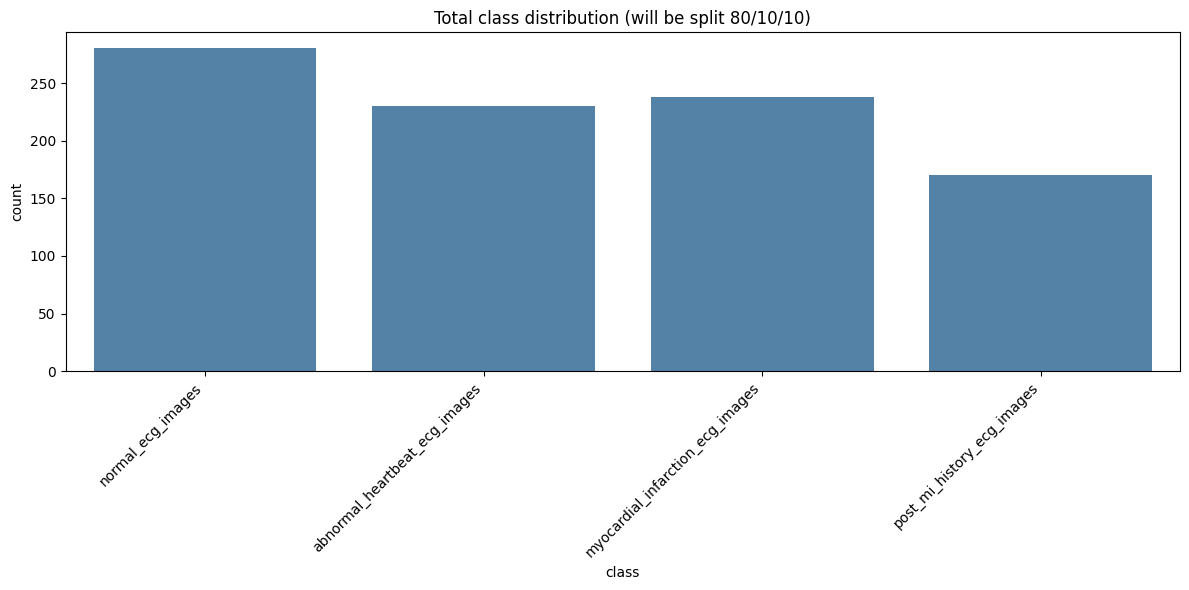

Saved: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\figures\class_distribution_total.png

Total counts per class:
  normal_ecg_images                                 :  280
  abnormal_heartbeat_ecg_images                     :  230
  myocardial_infarction_ecg_images                  :  238
  post_mi_history_ecg_images                        :  170


In [34]:
# EDA: class distribution (updated for direct class folders in ECG_DATA)
import matplotlib.pyplot as plt
import seaborn as sns

# Check if data is directly in ECG_DATA (no train/val/test splits)
base = Path(DATA_ROOT)
has_splits = (base/"train").exists() or (base/"val").exists() or (base/"test").exists()

if not has_splits:
    # Data is directly in class folders under ECG_DATA
    print("📁 Data structure: Class folders directly in ECG_DATA (no train/val/test splits)")
    print("Will auto-split into train/val/test (80/10/10) during training\n")
    
    splits = []
    total_counts = []
    for cname in CLASSES:
        cdir = base / cname
        if cdir.exists():
            cnt = sum(len(list(cdir.glob(pat))) for pat in EXTS)
            total_counts.append({"class": cname, "count": cnt})
    
    if total_counts:
        df_counts = pd.DataFrame(total_counts)
        plt.figure(figsize=(12,6))
        sns.barplot(data=df_counts, x="class", y="count", color="steelblue")
        plt.xticks(rotation=45, ha="right")
        plt.title("Total class distribution (will be split 80/10/10)")
        plt.tight_layout()
        fig_path = FIG_DIR / "class_distribution_total.png"
        plt.savefig(fig_path, dpi=200)
        plt.show()
        print("Saved:", fig_path)
        
        print("\nTotal counts per class:")
        for _, row in df_counts.iterrows():
            print(f"  {row['class'][:50]:50s}: {row['count']:4d}")
else:
    # Original logic for train/val/test split folders
    available_splits = []
    for split in ["train","val","test"]:
        split_base = base / split
        if split_base.exists() and any((split_base / cname).exists() for cname in CLASSES):
            available_splits.append(split)

    print(f"📁 Data structure: Organized in train/val/test splits")
    print(f"Available splits: {available_splits}\n")

    splits = []
    for split in available_splits:
        split_base = base / split
        for cname in CLASSES:
            cdir = split_base / cname
            if cdir.exists():
                cnt = sum(len(list(cdir.glob(pat))) for pat in EXTS)
                splits.append({"split": split, "class": cname, "count": cnt})

    if splits:
        df_counts = pd.DataFrame(splits)
        plt.figure(figsize=(12,6))
        sns.barplot(data=df_counts, x="class", y="count", hue="split")
        plt.xticks(rotation=45, ha="right")
        plt.title(f"Class distribution by split (Available: {', '.join(available_splits)})")
        plt.tight_layout()
        fig_path = FIG_DIR / "class_distribution_by_split.png"
        plt.savefig(fig_path, dpi=200)
        plt.show()
        print("Saved:", fig_path)
        
        print("\nDetailed counts:")
        for split in available_splits:
            print(f"\n{split.upper()}:")
            split_data = df_counts[df_counts['split'] == split]
            for _, row in split_data.iterrows():
                print(f"  {row['class'][:50]:50s}: {row['count']:4d}")

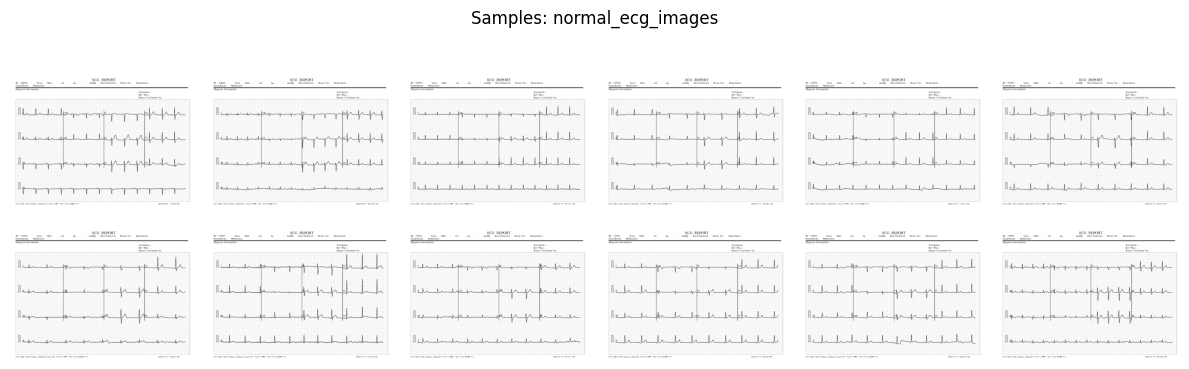

Saved: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\figures\samples_normal_ecg_images.png


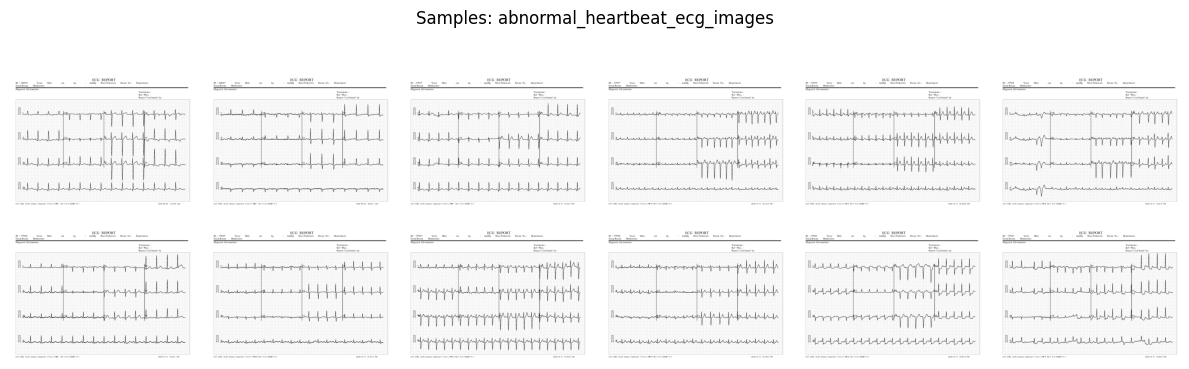

Saved: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\figures\samples_abnormal_heartbeat_ecg_images.png


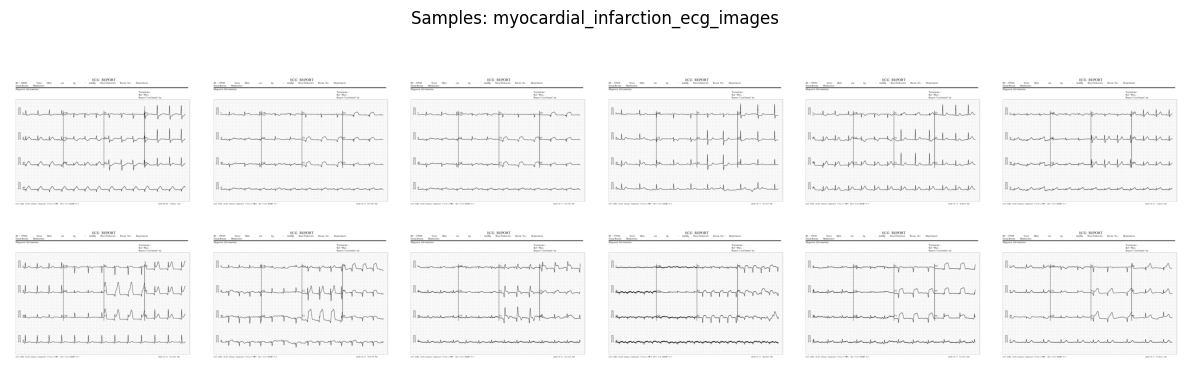

Saved: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\figures\samples_myocardial_infarction_ecg_imag.png


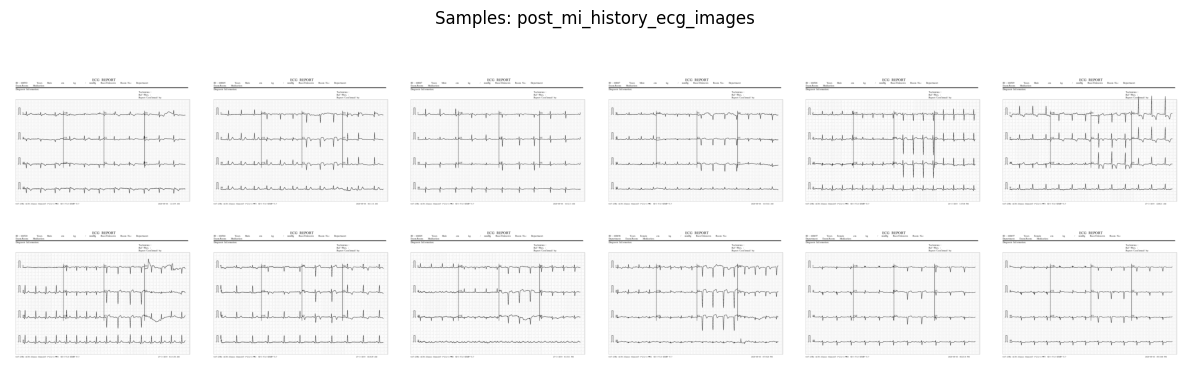

Saved: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\figures\samples_post_mi_history_ecg_images.png


In [35]:
# EDA: per-class sample grid (up to 12 per class)
import math
from PIL import Image

base = Path(DATA_ROOT)
has_splits = (base/"train").exists()

for cname in CLASSES:
    # Try train folder first, then direct class folder
    if has_splits:
        cdir = base / "train" / cname
    else:
        cdir = base / cname
    
    imgs = []
    if cdir.exists():
        for ext in EXTS:
            imgs += list(cdir.glob(ext))
    if not imgs:
        print(f"⚠️  No images found for class: {cname}")
        continue
    
    show = imgs[:12]
    cols = 6
    rows = math.ceil(len(show)/cols)
    plt.figure(figsize=(cols*2, rows*2))
    for i, p in enumerate(show, 1):
        plt.subplot(rows, cols, i)
        plt.imshow(Image.open(p).convert("L"), cmap="gray")
        plt.axis("off")
    plt.suptitle(f"Samples: {cname[:50]}")
    plt.tight_layout()
    fig_path = FIG_DIR / f"samples_{cname[:30].replace(' ','_')}.png"
    plt.savefig(fig_path, dpi=160)
    plt.show()
    print("Saved:", fig_path)

In [36]:
# ============= CWT Scalogram Generation =============
def generate_cwt_scalogram(signal_1d, scales=None, wavelet='morl', size=(224,224)):
    if scales is None:
        scales = np.arange(4, 65)  # 从 4 开始，不用 1~3
    coeffs, _ = pywt.cwt(signal_1d, scales, wavelet)

    scalogram = np.log1p(np.abs(coeffs))  # log 幅度更稳
    scalogram = (scalogram - scalogram.min()) / (scalogram.max() - scalogram.min() + 1e-8)
    scalogram = cv2.resize(scalogram, size, interpolation=cv2.INTER_LINEAR)
    return scalogram


# ============= R-Peak Detection =============
def detect_r_peaks(signal_1d, fs=500, distance=200):
    """
    Detect R-peaks in ECG signal using Pan-Tompkins-like approach.
    
    Args:
        signal_1d: 1D ECG signal
        fs: sampling frequency (Hz)
        distance: minimum distance between peaks (samples)
    
    Returns:
        r_peaks: array of R-peak indices
    """
    # Bandpass filter (5-15 Hz)
    b, a = signal.butter(2, [5, 15], btype='band', fs=fs)
    filtered = signal.filtfilt(b, a, signal_1d)
    
    # Derivative
    diff = np.diff(filtered)
    
    # Squaring
    squared = diff ** 2
    
    # Moving window integration
    window_size = int(0.15 * fs)  # 150ms window
    integrated = np.convolve(squared, np.ones(window_size)/window_size, mode='same')
    
    # Find peaks
    peaks, _ = signal.find_peaks(integrated, distance=distance, height=np.mean(integrated))
    
    return peaks


def compute_rr_intervals(r_peaks, fs=500, normalize=True, k=8):
    """
    Compute RR interval features from R-peaks.
    
    Args:
        r_peaks: array of R-peak indices
        fs: sampling frequency
        normalize: whether to normalize RR intervals
        k: number of RR intervals to return
    
    Returns:
        rr_features: array of k RR interval features
    """
    if len(r_peaks) < 2:
        return np.zeros(k, dtype=np.float32)
    
    # Compute RR intervals in milliseconds
    rr_intervals = np.diff(r_peaks) / fs * 1000
    
    # Normalize if requested
    if normalize and len(rr_intervals) > 0:
        rr_mean = np.mean(rr_intervals)
        rr_std = np.std(rr_intervals) + 1e-6
        rr_intervals = (rr_intervals - rr_mean) / rr_std
    
    # Pad or truncate to k features
    if len(rr_intervals) >= k:
        rr_features = rr_intervals[:k]
    else:
        rr_features = np.pad(rr_intervals, (0, k - len(rr_intervals)), mode='constant')
    
    return rr_features.astype(np.float32)

import numpy as np
import cv2
from PIL import Image

def crop_rhythm_strip(img_pil: Image.Image, bottom_ratio: float = 0.32) -> Image.Image:
    arr = np.array(img_pil)
    h, w = arr.shape[:2]
    y0 = int(h * (1 - bottom_ratio))
    return Image.fromarray(arr[y0:h, :])

def suppress_grid_gray(gray_u8: np.ndarray) -> np.ndarray:
    g = cv2.GaussianBlur(gray_u8, (3, 3), 0)
    inv = 255 - g
    bw = cv2.adaptiveThreshold(inv, 255,
                               cv2.ADAPTIVE_THRESH_MEAN_C,
                               cv2.THRESH_BINARY,
                               31, -5)
    h, w = bw.shape
    kx = max(10, w // 80)
    ky = max(10, h // 80)
    horiz = cv2.morphologyEx(bw, cv2.MORPH_OPEN,
                             cv2.getStructuringElement(cv2.MORPH_RECT, (kx, 1)))
    vert  = cv2.morphologyEx(bw, cv2.MORPH_OPEN,
                             cv2.getStructuringElement(cv2.MORPH_RECT, (1, ky)))
    grid = cv2.bitwise_or(horiz, vert)
    grid = cv2.dilate(grid, cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)), iterations=1)
    out = gray_u8.copy()
    out[grid > 0] = np.clip(out[grid > 0] + 60, 0, 255)
    return out

def extract_ecg_from_image(image_pil, band_ratio: float = 0.55) -> np.ndarray:
    # 1) rhythm strip
    image_pil = crop_rhythm_strip(image_pil.convert("L"), bottom_ratio=0.32)

    gray = np.array(image_pil, dtype=np.uint8)
    gray = suppress_grid_gray(gray)

    h, w0 = gray.shape

    # 2) 左右裁剪（去边框/刻度/留白）
    x0 = int(w0 * 0.06)
    x1 = int(w0 * 0.94)
    gray = gray[:, x0:x1]
    h, w = gray.shape

    # 3) 取中间大带
    y0 = int(h * (0.5 - band_ratio / 2))
    y1 = int(h * (0.5 + band_ratio / 2))
    y0 = max(0, y0); y1 = min(h, y1)
    strip = gray[y0:y1, :]
    bh = strip.shape[0]

    inv = 255.0 - strip.astype(np.float32)

    # ★ 关键改动 1：提高阈值，只信“最黑的那部分”，减少网格残留
    thr = np.percentile(inv, 96)          # 原来 92 -> 96（如果太稀疏可降到 95）
    wgt = np.clip(inv - thr, 0, None)

    ys = np.arange(bh, dtype=np.float32)[:, None]
    denom = wgt.sum(axis=0)

    # ★ 关键改动 2：更严格的有效列筛选（防止噪声列影响 yhat）
    eps = 1e-6
    denom_thr = np.percentile(denom, 50)  # 原来 30 -> 50（更严格；不够可降到 40）
    valid = denom > denom_thr
    denom_safe = denom + eps

    yhat = (ys * wgt).sum(axis=0) / denom_safe
    yhat[~valid] = np.nan

    # 5) 插值填 nan
    x = np.arange(w, dtype=np.float32)
    good = ~np.isnan(yhat)
    if good.sum() >= 2:
        yhat = np.interp(x, x[good], yhat[good])
    else:
        yhat = np.full_like(x, bh / 2.0)

    # 6) 转成波形
    sig = (bh / 2.0 - yhat)

    # 平滑（短窗）
    k = 31
    kernel = np.ones(k, dtype=np.float32) / k
    sig = np.convolve(sig, kernel, mode="same")

    # ★ 关键改动 3：baseline removal（长窗去基线，CWT 会干净很多）
    k2 = 201
    kernel2 = np.ones(k2, dtype=np.float32) / k2
    baseline = np.convolve(sig, kernel2, mode="same")
    sig = sig - baseline

    # 去极值（winsorize）
    lo, hi = np.percentile(sig, [1, 99])
    sig = np.clip(sig, lo, hi)

    # 标准化
    sig = (sig - sig.mean()) / (sig.std() + 1e-6)

    # 去掉左右 2%（再插值回原长度）
    w = sig.shape[0]
    l = int(w * 0.02)
    r = int(w * 0.98)
    sig_mid = sig[l:r]

    x_old = np.linspace(0, 1, sig_mid.shape[0])
    x_new = np.linspace(0, 1, w)
    sig = np.interp(x_new, x_old, sig_mid).astype(np.float32)

    return sig

# Dataset and utilities

In [37]:
USE_CWT = True  # Set to True to use CWT scalograms, False to use raw images
RR_DIM = 0     # Number of RR intervals to extract

def map_to_binary_label(folder_name: str) -> int:
    """
    normal_ecg_images -> 0
    others -> 1
    """
    if folder_name == "normal_ecg_images":
        return 0
    return 1

def default_transforms(train=True):
    if train:
        return T.Compose([
            T.Grayscale(num_output_channels=1),
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.RandomAffine(degrees=8, translate=(0.06, 0.06), scale=(0.92, 1.08), shear=5),
            T.RandomPerspective(distortion_scale=0.25, p=0.4),
            T.ColorJitter(brightness=0.35, contrast=0.35),
            T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.2)),
            T.RandomErasing(p=0.35, scale=(0.01, 0.08), ratio=(0.3, 3.0), value=0),
            T.ToTensor(),
            T.Normalize(mean=[0.5], std=[0.5]),
        ])
    else:
        return T.Compose([
            T.Grayscale(num_output_channels=1),
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.ToTensor(),
            T.Normalize(mean=[0.5], std=[0.5]),
        ])
        
def load_rr_map(rr_csv, k=8):
    """Load RR CSV (optional): columns filepath, rr1..rrk; return dict and dimension k."""
    if not rr_csv or not Path(rr_csv).exists():
        return {}, 0
    df = pd.read_csv(rr_csv)
    rr_cols = [c for c in df.columns if c.lower().startswith("rr")][:k]
    mp = {}
    for _, row in df.iterrows():
        key = str(row["filepath"]).replace("\\", "/")
        mp[key] = row[rr_cols].astype(float).to_numpy(dtype="float32")
    return mp, len(rr_cols)

def _scan_folder(folder: Path) -> List[Path]:
    files = []
    for pat in EXTS:
        files += list(folder.glob(pat))
    return sorted(files)

class ECGBeatImages(Dataset):
    """Standard Dataset for existing train/val/test directories (relative path method)"""
    def __init__(self, root, split, transform=None, rr_map=None, rr_dim=RR_DIM, use_cwt=USE_CWT):
        self.root = Path(root) / split
        self.transform = transform or default_transforms(train=(split == "train"))
        self.rr_map = rr_map or {}
        self.rr_dim = rr_dim
        self.use_cwt = use_cwt
        self.samples = []  # (rel_path, binary_label)

        for cname in CLASSES:
            cls_dir = self.root / cname
            if not cls_dir.exists():
                continue
            binary_label = map_to_binary_label(cname)
            for p in _scan_folder(cls_dir):
                rel = f"{split}/{cname}/{p.name}"
                self.samples.append((rel, binary_label))

        assert len(self.samples) > 0, (
            f"No images found under: {self.root}\n"
            f"Expected folders: {', '.join(CLASSES)}"
        )
        print(f"{split}: {len(self.samples)} samples (CWT={'ON' if use_cwt else 'OFF'})")

    def __len__(self):
        return len(self.samples)
    

class ECGFilesDataset(Dataset):
    """Dataset for direct class folders, auto split (absolute path method)"""
    def __init__(self, items: List[Tuple[str, int]], root, transform=None, rr_map=None, rr_dim=RR_DIM, train=True, use_cwt=USE_CWT):
        self.items = items
        self.root = Path(root)
        self.transform = transform or default_transforms(train=train)
        self.rr_map = rr_map or {}
        self.rr_dim = rr_dim
        self.train = train
        self.use_cwt = use_cwt

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        path, y = self.items[i]
        img_pil = Image.open(path).convert("L")

        abs_path = Path(path).resolve()
        abs_root = self.root.resolve()
        rel = str(abs_path.relative_to(abs_root)).replace("\\", "/")

        # 只有在需要 CWT 或 RR 时才提取 1D（避免无谓计算）
        signal_1d = None
        if self.use_cwt or self.rr_dim > 0:
            # 这个函数用你刚换的“rhythm strip + 去网格 + 暗像素重心”版本
            signal_1d = extract_ecg_from_image(img_pil)

        # Generate CWT scalogram or use raw image
        if self.use_cwt:
            scalogram = generate_cwt_scalogram(signal_1d, size=(IMG_SIZE, IMG_SIZE))
            img_tensor = torch.from_numpy(scalogram).unsqueeze(0).float()
        else:
            img_tensor = self.transform(img_pil)

        # RR：强烈建议先关掉（rr_dim=0），泛化更稳
        if self.rr_dim > 0:
            if rel in self.rr_map:
                rr = self.rr_map[rel]
            else:
                try:
                    r_peaks = detect_r_peaks(signal_1d, fs=500)
                    rr = compute_rr_intervals(r_peaks, k=self.rr_dim)
                except Exception:
                    rr = np.zeros(self.rr_dim, dtype=np.float32)
        else:
            rr = np.zeros(0, dtype=np.float32)  # rr_dim=0 时返回空向量更干净

        return img_tensor, torch.tensor(rr, dtype=torch.float32), torch.tensor(y, dtype=torch.long), rel
def list_paths(base_dir: Path) -> List[Tuple[str, int]]:
    """Scan class folders directly under base_dir for images and map to binary labels"""
    items = []
    for cname in CLASSES:
        cls_dir = base_dir / cname
        if cls_dir.exists():
            binary_label = map_to_binary_label(cname)
            for p in _scan_folder(cls_dir):
                items.append((str(p.resolve()), binary_label))
    return items

def make_loaders(rr_csv=RR_CSV, batch=BATCH_SIZE):
    """
    Auto-detect data structure and create loaders:
    1. If train/val/test folders exist: use them directly
    2. Otherwise: auto split from class folders (80/20, use test as validation)
    """
    rr_map, rr_dim = load_rr_map(rr_csv)
    base = Path(DATA_ROOT)

    has_val = (base / "val").exists()
    has_test = (base / "test").exists()
    has_train = (base / "train").exists()

    # Check if organized in train/val/test structure
    if has_train and has_val and has_test:
        print("📂 Using existing train/val/test split folders")
        ds_tr = ECGBeatImages(DATA_ROOT, "train", default_transforms(True), rr_map, rr_dim)
        ds_va = ECGBeatImages(DATA_ROOT, "val",   default_transforms(False), rr_map, rr_dim)
        ds_te = ECGBeatImages(DATA_ROOT, "test",  default_transforms(False), rr_map, rr_dim)
        labels_tr = [lab for _, lab in ds_tr.samples]

    else:
        # Data is directly in class folders - auto split 80/10/10
        print("📂 Class folders detected - auto-splitting 80/10/10 (train/val/test)")
        all_items = list_paths(base)
        assert len(all_items) > 0, f"No images found under {base}\nExpected class folders: {', '.join(CLASSES)}"

        # ---- Stratified split: 80/10/10 ----
        by_cls = {}
        for path, lab in all_items:
            by_cls.setdefault(lab, []).append((path, lab))

        rng = np.random.RandomState(SEED)
        items_tr, items_va, items_te = [], [], []

        for lab, items in by_cls.items():
            rng.shuffle(items)
            n = len(items)

            n_te = max(1, int(0.1 * n))   # 10% test
            n_va = max(1, int(0.1 * n))   # 10% val
            n_tr = n - n_va - n_te

            # 防止极小类被切坏
            if n_tr < 1:
                n_tr = max(1, n - 2)
                n_va = 1
                n_te = n - n_tr - n_va

            items_tr += items[:n_tr]
            items_va += items[n_tr:n_tr + n_va]
            items_te += items[n_tr + n_va:]

        print("✅ Auto split complete (80/10/10):")
        print(f"   Train: {len(items_tr)} samples")
        print(f"   Val:   {len(items_va)} samples")
        print(f"   Test:  {len(items_te)} samples")

        ds_tr = ECGFilesDataset(items_tr, DATA_ROOT, default_transforms(True), rr_map, rr_dim, train=True)
        ds_va = ECGFilesDataset(items_va, DATA_ROOT, default_transforms(False), rr_map, rr_dim, train=False)
        ds_te = ECGFilesDataset(items_te, DATA_ROOT, default_transforms(False), rr_map, rr_dim, train=False)
        labels_tr = [lab for _, lab in items_tr]

    # Weighted sampling for balanced training (binary)
    counts = np.bincount(np.array(labels_tr), minlength=NUM_CLASSES)
    w_per_cls = counts.sum() / (counts + 1e-6)
    w_per_cls = w_per_cls * (NUM_CLASSES / w_per_cls.sum())
    weights = np.array([w_per_cls[y] for y in labels_tr], dtype="float32")
    sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

    print("Binary train class counts:")
    for i, c in enumerate(counts):
        print(f"  {CLASS_NAMES[i]}: {int(c)}")

    L_tr = DataLoader(ds_tr, batch_size=batch, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
    L_va = DataLoader(ds_va, batch_size=batch, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    L_te = DataLoader(ds_te, batch_size=batch, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    return L_tr, L_va, L_te, rr_dim

In [38]:
L_tr, L_va, L_te, rr_dim = make_loaders()

print("Train batches:", len(L_tr))
print("Val batches:", len(L_va))
print("Test batches:", len(L_te))

📂 Class folders detected - auto-splitting 80/10/10 (train/val/test)
✅ Auto split complete (80/10/10):
   Train: 736 samples
   Val:   91 samples
   Test:  91 samples
Binary train class counts:
  Normal: 224
  Abnormal: 512
Train batches: 46
Val batches: 6
Test batches: 6


In [39]:
items = list_paths(DATA_ROOT if not (Path(DATA_ROOT) / "train").exists() else Path(DATA_ROOT) / "train")
for p, y in items[:20]:
    print(Path(p).parent.name, "->", y, "->", CLASS_NAMES[y])

normal_ecg_images -> 0 -> Normal
normal_ecg_images -> 0 -> Normal
normal_ecg_images -> 0 -> Normal
normal_ecg_images -> 0 -> Normal
normal_ecg_images -> 0 -> Normal
normal_ecg_images -> 0 -> Normal
normal_ecg_images -> 0 -> Normal
normal_ecg_images -> 0 -> Normal
normal_ecg_images -> 0 -> Normal
normal_ecg_images -> 0 -> Normal
normal_ecg_images -> 0 -> Normal
normal_ecg_images -> 0 -> Normal
normal_ecg_images -> 0 -> Normal
normal_ecg_images -> 0 -> Normal
normal_ecg_images -> 0 -> Normal
normal_ecg_images -> 0 -> Normal
normal_ecg_images -> 0 -> Normal
normal_ecg_images -> 0 -> Normal
normal_ecg_images -> 0 -> Normal
normal_ecg_images -> 0 -> Normal


# Step 3. Model (DS-Res-SE + optional RR-TCN)

In [40]:

class SE2D(nn.Module):
    """Squeeze-and-Excitation 2D"""
    def __init__(self, c, r=16):
        super().__init__()
        self.fc1 = nn.Conv2d(c, c//r, 1)
        self.fc2 = nn.Conv2d(c//r, c, 1)
    
    def forward(self, x):
        s = F.adaptive_avg_pool2d(x, 1)
        s = F.relu(self.fc1(s))
        s = torch.sigmoid(self.fc2(s))
        return x * s


class DSRes2D(nn.Module):
    """Depthwise Separable Residual Block"""
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.dw = nn.Conv2d(in_c, in_c, 3, stride=stride, padding=1, groups=in_c, bias=False)
        self.pw = nn.Conv2d(in_c, out_c, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(in_c)
        self.bn2 = nn.BatchNorm2d(out_c)
        self.se = SE2D(out_c)
        self.proj = nn.Conv2d(in_c, out_c, 1, stride=stride, bias=False) if (in_c!=out_c or stride!=1) else None
    
    def forward(self, x):
        idn = x
        x = F.relu(self.bn1(self.dw(x)))
        x = self.bn2(self.pw(x))
        x = self.se(F.relu(x))
        if self.proj is not None:
            idn = self.proj(idn)
        return F.relu(x + idn)


class MorphologyCNN(nn.Module):
    """Morphology CNN for image feature extraction"""
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.MaxPool2d(2)
        )
        self.b1 = DSRes2D(32, 64, stride=2)
        self.b2 = DSRes2D(64, 128, stride=2)
        self.b3 = DSRes2D(128, 128, stride=2)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 256)
        )
    
    def forward(self, x):
        x = self.stem(x)
        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)
        return self.head(x)


class TCNBlock(nn.Module):
    """Temporal Convolutional Network Block"""
    def __init__(self, in_c, out_c, k=3, d=1):
        super().__init__()
        pad = (k-1)//2 * d
        self.c1 = nn.Conv1d(in_c, out_c, k, padding=pad, dilation=d)
        self.c2 = nn.Conv1d(out_c, out_c, k, padding=pad, dilation=d)
        self.bn1 = nn.BatchNorm1d(out_c)
        self.bn2 = nn.BatchNorm1d(out_c)
        self.proj = nn.Conv1d(in_c, out_c, 1) if in_c!=out_c else None
    
    def forward(self, x):
        idn = x
        x = F.relu(self.bn1(self.c1(x)))
        x = self.bn2(self.c2(x))
        if self.proj is not None:
            idn = self.proj(idn)
        return F.relu(x + idn)


class RR_TCN(nn.Module):
    def __init__(self, rr_dim, out_dim=64):
        super().__init__()
        self.rr_dim = int(rr_dim)
        if self.rr_dim <= 0:
            self.enabled = False
            self.out_dim = 0
            self.net = None
            return

        self.enabled = True
        self.out_dim = out_dim

        # 下面保持你原本RR_TCN的结构即可（Conv1d/TCN/MLP都行）
        self.net = nn.Sequential(
            nn.Linear(self.rr_dim, 128),
            nn.ReLU(True),
            nn.Dropout(0.1),
            nn.Linear(128, out_dim),
            nn.ReLU(True),
        )

    def forward(self, rr):
        if not self.enabled:
            # rr 的 shape 是 (B,0) 或 (B,rr_dim)，我们返回 (B,0)
            B = rr.shape[0]
            return rr.new_zeros((B, 0))
        return self.net(rr)


print("✓ Basic modules loaded (SE2D, DSRes2D, MorphologyCNN, TCNBlock, RR_TCN)")


✓ Basic modules loaded (SE2D, DSRes2D, MorphologyCNN, TCNBlock, RR_TCN)


In [41]:
class DualBranchSelfAttention(nn.Module):
    """
    Self-attention between morphology feature and RR feature.
    将 fm 和 fr 视为两个 token，做真正的自注意力交互。
    """
    def __init__(self, fm_dim=256, fr_dim=64, attn_dim=256, num_heads=4, dropout=0.1):
        super().__init__()

        self.fm_proj = nn.Linear(fm_dim, attn_dim)
        self.fr_proj = nn.Linear(fr_dim, attn_dim) if fr_dim > 0 else None

        self.attn = nn.MultiheadAttention(
            embed_dim=attn_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(attn_dim)
        self.norm2 = nn.LayerNorm(attn_dim)

        self.ffn = nn.Sequential(
            nn.Linear(attn_dim, attn_dim),
            nn.ReLU(True),
            nn.Dropout(dropout),
            nn.Linear(attn_dim, attn_dim)
        )

        self.dropout = nn.Dropout(dropout)
        self.has_rr = fr_dim > 0
        self.attn_dim = attn_dim

    def forward(self, fm, fr=None):
        """
        fm: [B, 256]
        fr: [B, fr_dim] or [B, 0]
        return:
            if has_rr: [B, 2*attn_dim]
            else:      [B, attn_dim]
        """
        fm_tok = self.fm_proj(fm).unsqueeze(1)   # [B,1,D]

        if self.has_rr and fr is not None and fr.shape[1] > 0:
            fr_tok = self.fr_proj(fr).unsqueeze(1)   # [B,1,D]
            x = torch.cat([fm_tok, fr_tok], dim=1)   # [B,2,D]
        else:
            x = fm_tok                                # [B,1,D]

        attn_out, _ = self.attn(x, x, x, need_weights=False)
        x = self.norm1(x + self.dropout(attn_out))

        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))

        x = x.reshape(x.size(0), -1)  # [B, 2D] or [B, D]
        return x

In [42]:
# ============================================================================
# RAG (Retrieval-Augmented Generation) Module
# ============================================================================

class RAGModule(nn.Module):
    """
    Retrieval-Augmented Generation for ECG Classification
    检索增强生成模块：通过检索相似样本来增强特征表示
    """
    def __init__(self, feature_dim=256, num_prototypes=200, num_classes=4):
        super().__init__()
        self.feature_dim = feature_dim
        self.num_prototypes = num_prototypes
        self.num_classes = num_classes
        
        # 原型特征库
        self.register_buffer('prototypes', torch.randn(num_prototypes, feature_dim))
        self.register_buffer('prototype_labels', torch.zeros(num_prototypes, dtype=torch.long))
        self.register_buffer('prototype_initialized', torch.tensor(False))
        
        # 特征融合网络
        self.fusion = nn.Sequential(
            nn.Linear(feature_dim * 2, feature_dim),
            nn.ReLU(True),
            nn.Dropout(0.1),
            nn.Linear(feature_dim, feature_dim)
        )
        
        # 注意力权重
        self.attention = nn.Sequential(
            nn.Linear(feature_dim * 2, 128),
            nn.ReLU(True),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
        
    def initialize_prototypes(self, features, labels):
        """从训练数据初始化原型库"""
        if self.prototype_initialized:
            return
        
        prototypes_list = []
        labels_list = []
        samples_per_class = self.num_prototypes // self.num_classes
        
        for c in range(self.num_classes):
            class_mask = (labels == c)
            class_features = features[class_mask]
            
            if len(class_features) > 0:
                if len(class_features) >= samples_per_class:
                    indices = torch.randperm(len(class_features))[:samples_per_class]
                    selected = class_features[indices]
                else:
                    selected = class_features[torch.randint(0, len(class_features), (samples_per_class,))]
                
                prototypes_list.append(selected)
                labels_list.append(torch.full((samples_per_class,), c, dtype=torch.long))
        
        if prototypes_list:
            self.prototypes = torch.cat(prototypes_list, dim=0).to(self.prototypes.device)
            self.prototype_labels = torch.cat(labels_list, dim=0).to(self.prototype_labels.device)
            self.prototype_initialized = torch.tensor(True)
            print(f"✓ RAG prototypes initialized: {self.prototypes.shape}")
    
    def retrieve(self, query_features, k=5):
        """检索最相似的k个原型"""
        query_norm = F.normalize(query_features, p=2, dim=1)
        proto_norm = F.normalize(self.prototypes, p=2, dim=1)
        similarities = torch.mm(query_norm, proto_norm.t())
        top_k_sim, top_k_idx = similarities.topk(k, dim=1)
        retrieved_features = self.prototypes[top_k_idx]
        retrieved_labels = self.prototype_labels[top_k_idx]
        return retrieved_features, retrieved_labels, top_k_sim
    
    def forward(self, query_features):
        """使用检索到的相似样本增强当前特征"""
        if not self.prototype_initialized:
            return query_features
        
        retrieved_features, retrieved_labels, similarities = self.retrieve(query_features, k=5)
        weights = F.softmax(similarities * 10, dim=1).unsqueeze(2)
        aggregated = (retrieved_features * weights).sum(dim=1)
        combined = torch.cat([query_features, aggregated], dim=1)
        alpha = self.attention(combined)
        fused = self.fusion(combined)
        augmented_features = query_features + alpha * fused
        return augmented_features


# =========== Model Architectures ===========

# 1. Pure CNN Model
class PureCNN(nn.Module):
    """Pure CNN architecture for ECG classification"""
    def __init__(self, num_classes, rr_dim=0, use_rag=False):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2)
        )
        self.conv1 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.MaxPool2d(2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.MaxPool2d(2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.MaxPool2d(2)
        )
        
        self.rrnet = RR_TCN(rr_dim)
        fuse_in = 256 * 14 * 14 + self.rrnet.out_dim
        
        self.feature_extractor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(fuse_in, 512),
            nn.ReLU(True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(True),
            nn.Dropout(0.2)
        )
        
        self.use_rag = use_rag
        if use_rag:
            self.rag = RAGModule(feature_dim=256, num_prototypes=200, num_classes=num_classes)
        
        self.classifier = nn.Linear(256, num_classes)
    
    def forward(self, img, rr):
        x = self.stem(img)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size(0), -1)
        fr = self.rrnet(rr)
        z = torch.cat([x, fr], dim=1)
        z = self.feature_extractor(z)
        
        if self.use_rag:
            z = self.rag(z)
        
        return self.classifier(z)


# 2. CNN-LSTM Hybrid Model
class CNNLSTM(nn.Module):
    """CNN-LSTM hybrid architecture for ECG classification"""
    def __init__(self, num_classes, rr_dim=0, use_rag=False):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.MaxPool2d(2),
        )
        
        self.lstm1 = nn.LSTM(128 * 56, 256, batch_first=True, bidirectional=False)
        self.lstm2 = nn.LSTM(256, 128, batch_first=True, bidirectional=False)
        self.dropout = nn.Dropout(0.3)
        
        self.rrnet = RR_TCN(rr_dim)
        fuse_in = 128 + self.rrnet.out_dim
        
        self.feature_extractor = nn.Sequential(
            nn.Linear(fuse_in, 256),
            nn.ReLU(True),
            nn.Dropout(0.2)
        )
        
        self.use_rag = use_rag
        if use_rag:
            self.rag = RAGModule(feature_dim=256, num_prototypes=200, num_classes=num_classes)
        
        self.classifier = nn.Linear(256, num_classes)
    
    def forward(self, img, rr):
        x = self.cnn(img)
        B, C, H, W = x.shape
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(B, H, -1)
        x, _ = self.lstm1(x)
        x = self.dropout(x)
        x, _ = self.lstm2(x)
        x = x[:, -1, :]
        fr = self.rrnet(rr)
        z = torch.cat([x, fr], dim=1)
        z = self.feature_extractor(z)
        
        if self.use_rag:
            z = self.rag(z)
        
        return self.classifier(z)


# 3. Pure LSTM Model
class PureLSTM(nn.Module):
    """Pure LSTM architecture for ECG classification"""
    def __init__(self, num_classes, rr_dim=0, use_rag=False):
        super().__init__()
        self.lstm1 = nn.LSTM(224, 256, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(512, 128, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        
        self.rrnet = RR_TCN(rr_dim)
        fuse_in = 256 + self.rrnet.out_dim
        
        self.feature_extractor = nn.Sequential(
            nn.Linear(fuse_in, 256),
            nn.ReLU(True),
            nn.Dropout(0.2)
        )
        
        self.use_rag = use_rag
        if use_rag:
            self.rag = RAGModule(feature_dim=256, num_prototypes=200, num_classes=num_classes)
        
        self.classifier = nn.Linear(256, num_classes)
    
    def forward(self, img, rr):
        B, C, H, W = img.shape
        x = img.squeeze(1)
        x, _ = self.lstm1(x)
        x = self.dropout(x)
        x, _ = self.lstm2(x)
        x = x[:, -1, :]
        fr = self.rrnet(rr)
        z = torch.cat([x, fr], dim=1)
        z = self.feature_extractor(z)
        
        if self.use_rag:
            z = self.rag(z)
        
        return self.classifier(z)


# 4. Enhanced SE-Attention
class EnhancedSE2D(nn.Module):
    """Enhanced SE attention applied after each conv block"""
    def __init__(self, c, r=16):
        super().__init__()
        self.fc1 = nn.Conv2d(c, max(c//r, 4), 1)
        self.fc2 = nn.Conv2d(max(c//r, 4), c, 1)
    
    def forward(self, x):
        s = F.adaptive_avg_pool2d(x, 1)
        s = F.relu(self.fc1(s))
        s = torch.sigmoid(self.fc2(s))
        return x * s


class EnhancedDSResSE(nn.Module):
    """DS-Res with Enhanced SE"""
    def __init__(self, num_classes, rr_dim=0, use_rag=False):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            EnhancedSE2D(32),
            nn.ReLU(True),
            nn.MaxPool2d(2)
        )
        
        self.b1_conv = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            EnhancedSE2D(64),
            nn.ReLU(True),
            nn.MaxPool2d(2)
        )
        
        self.b2_conv = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            EnhancedSE2D(128),
            nn.ReLU(True),
            nn.MaxPool2d(2)
        )
        
        self.b3_conv = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            EnhancedSE2D(128),
            nn.ReLU(True),
            nn.MaxPool2d(2)
        )
        
        self.rrnet = RR_TCN(rr_dim)
        fuse_in = 128 * 14 * 14 + self.rrnet.out_dim
        
        self.feature_extractor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(fuse_in, 512),
            nn.ReLU(True),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(True),
            nn.Dropout(0.2)
        )
        
        self.use_rag = use_rag
        if use_rag:
            self.rag = RAGModule(feature_dim=256, num_prototypes=200, num_classes=num_classes)
        
        self.classifier = nn.Linear(256, num_classes)
    
    def forward(self, img, rr):
        x = self.stem(img)
        x = self.b1_conv(x)
        x = self.b2_conv(x)
        x = self.b3_conv(x)
        x = x.view(x.size(0), -1)
        fr = self.rrnet(rr)
        z = torch.cat([x, fr], dim=1)
        z = self.feature_extractor(z)
        
        if self.use_rag:
            z = self.rag(z)
        
        return self.classifier(z)


# 5. DSRFromImages with RAG (Main Model)
class DSRFromImages(nn.Module):
    """
    Depthwise Separable Residual Network with Self-Attention + RAG
    """
    def __init__(self, num_classes, rr_dim=0, use_rag=True):
        super().__init__()
        self.morph = MorphologyCNN()
        self.rrnet = RR_TCN(rr_dim)

        self.self_attn_fusion = DualBranchSelfAttention(
            fm_dim=256,
            fr_dim=self.rrnet.out_dim,
            attn_dim=256,
            num_heads=4,
            dropout=0.1
        )

        attn_out_dim = 256 * 2 if self.rrnet.out_dim > 0 else 256

        self.fuse = nn.Sequential(
            nn.Linear(attn_out_dim, 256),
            nn.ReLU(True),
            nn.Dropout(0.2)
        )

        self.use_rag = use_rag
        if use_rag:
            self.rag = RAGModule(
                feature_dim=256,
                num_prototypes=200,
                num_classes=num_classes
            )
            print("✓ DSRFromImages with Self-Attention + RAG enabled")
        else:
            print("✓ DSRFromImages with Self-Attention enabled")

        self.cls = nn.Linear(256, num_classes)

    def forward(self, img, rr):
        fm = self.morph(img)      # [B,256]
        fr = self.rrnet(rr)       # [B,rr_out_dim] or [B,0]

        z = self.self_attn_fusion(fm, fr)
        z = self.fuse(z)

        if self.use_rag:
            z = self.rag(z)

        return self.cls(z)


print("="*80)
print("✓ Model architectures loaded with RAG support:")
print("  - DSRFromImages (Main: DS-Res + Wavelet + Temporal + RAG)")
print("  - EnhancedDSResSE (Enhanced SE-Attention + optional RAG)")
print("  - PureCNN (4 conv blocks + optional RAG)")
print("  - CNNLSTM (CNN + LSTM hybrid + optional RAG)")
print("  - PureLSTM (Bidirectional LSTM + optional RAG)")
print("="*80)


✓ Model architectures loaded with RAG support:
  - DSRFromImages (Main: DS-Res + Wavelet + Temporal + RAG)
  - EnhancedDSResSE (Enhanced SE-Attention + optional RAG)
  - PureCNN (4 conv blocks + optional RAG)
  - CNNLSTM (CNN + LSTM hybrid + optional RAG)
  - PureLSTM (Bidirectional LSTM + optional RAG)


In [43]:
def run_epoch_fixed(model, loader, optimizer=None, criterion=None, train=True,
                    scaler=None, accumulation_steps=1):
    """
    Run one epoch of training or evaluation
    """
    if train:
        model.train()
        assert optimizer is not None and criterion is not None
    else:
        model.eval()

    all_preds = []
    all_labels = []
    all_probs = []
    total_loss = 0.0
    num_batches = 0

    if train:
        optimizer.zero_grad()

    with torch.set_grad_enabled(train):
        for batch_idx, (img, rr, labels, _) in enumerate(
            tqdm(loader, desc="Train" if train else "Eval", leave=False)
        ):
            img = img.to(DEVICE, non_blocking=True)
            rr = rr.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if train and scaler is not None:
                with torch.cuda.amp.autocast():
                    outputs = model(img, rr)
                    loss = criterion(outputs, labels)
                    loss = loss / accumulation_steps

                scaler.scale(loss).backward()

                if (batch_idx + 1) % accumulation_steps == 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()

            elif train:
                outputs = model(img, rr)
                loss = criterion(outputs, labels)
                loss = loss / accumulation_steps
                loss.backward()

                if (batch_idx + 1) % accumulation_steps == 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    optimizer.zero_grad()

            else:
                if scaler is not None:
                    with torch.cuda.amp.autocast():
                        outputs = model(img, rr)
                else:
                    outputs = model(img, rr)

                if criterion is not None:
                    loss = criterion(outputs, labels)
                else:
                    loss = torch.tensor(0.0, device=labels.device)

            with torch.no_grad():
                probs = F.softmax(outputs.float(), dim=1)
                preds = torch.argmax(probs, dim=1)

            all_probs.append(probs.detach().cpu().numpy())
            all_preds.append(preds.detach().cpu().numpy())
            all_labels.append(labels.detach().cpu().numpy())

            if train or criterion is not None:
                total_loss += loss.item() * accumulation_steps
            num_batches += 1

    all_probs = np.concatenate(all_probs, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # ✅ 二分类
    metrics = compute_metrics(all_labels, all_preds, all_probs, NUM_CLASSES)

    if train or criterion is not None:
        metrics["loss"] = total_loss / max(num_batches, 1)

    return metrics


In [44]:
def compute_metrics(y_true, y_pred, y_prob, num_classes=2):
    """
    Binary classification metrics.
    Positive class = 1 (Abnormal)
    """
    assert num_classes == 2, "This version is for binary classification only."

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)   # sensitivity
    specificity = tn / (tn + fp + 1e-8)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    prob_pos = y_prob[:, 1]

    try:
        roc_auc = roc_auc_score(y_true, prob_pos)
    except Exception:
        roc_auc = 0.0

    try:
        pr_auc = average_precision_score(y_true, prob_pos)
    except Exception:
        pr_auc = 0.0

    try:
        fpr, tpr, roc_thresholds = roc_curve(y_true, prob_pos)
    except Exception:
        fpr, tpr, roc_thresholds = np.array([0, 1]), np.array([0, 1]), np.array([0, 1])

    try:
        pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_true, prob_pos)
    except Exception:
        pr_precision = np.array([1, 0])
        pr_recall = np.array([0, 1])
        pr_thresholds = np.array([0.5])

    metrics = {
        "oa": accuracy,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "sensitivity": recall,
        "specificity": specificity,
        "f1": f1,
        "macro_f1": macro_f1,
        "macro_auc": roc_auc,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "confusion_matrix": cm,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "fpr": fpr,
        "tpr": tpr,
        "roc_thresholds": roc_thresholds,
        "pr_precision": pr_precision,
        "pr_recall": pr_recall,
        "pr_thresholds": pr_thresholds,
    }
    return metrics

print("✓ compute_metrics function loaded (Binary + ROC/PR)")

✓ compute_metrics function loaded (Binary + ROC/PR)


In [45]:
# =========== Enhanced Visualization with Legends (from spring.ipynb) ===========

def plot_multi_model_training_history(model_histories, model_names, save_dir=None):
    """
    Plot training history comparison for multiple models
    All plots include legends
    
    Args:
        model_histories: Dict of {model_name: history_dict}
        model_names: List of model names to plot
        save_dir: Directory to save plots
    """
    if save_dir:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
    
    # Define colors for different models
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
              '#8c564b', '#e377c2', '#7f7f7f']
    
    # 1. Training Loss Comparison
    plt.figure(figsize=(12, 6))
    for idx, name in enumerate(model_names):
        if name in model_histories and 'train_loss' in model_histories[name]:
            history = model_histories[name]['train_loss']
            final_loss = history[-1] if history else 0
            plt.plot(history, label=f'{name} (Final: {final_loss:.4f})', 
                    color=colors[idx % len(colors)], linewidth=2, marker='o', markersize=4, markevery=2)
            
            # 添加数值标签
            if history:
                plt.annotate(f'Loss={final_loss:.4f}', 
                           xy=(len(history)-1, final_loss), 
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=9, fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[idx % len(colors)], alpha=0.7))
    
    plt.xlabel('Epoch', fontsize=14, fontweight='bold')
    plt.ylabel('Loss', fontsize=14, fontweight='bold')
    plt.title('Training Loss Comparison Across Models', fontsize=16, fontweight='bold')
    plt.legend(loc='best', fontsize=11, frameon=True, shadow=True)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    if save_dir:
        plt.savefig(save_dir / 'train_loss_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2. Validation F1 Comparison
    plt.figure(figsize=(12, 6))
    for idx, name in enumerate(model_names):
        if name in model_histories and 'val_f1' in model_histories[name]:
            history = model_histories[name]['val_f1']
            best_f1 = max(history) if history else 0
            plt.plot(history, label=f'{name} (Best: {best_f1:.4f})', 
                    color=colors[idx % len(colors)], linewidth=2, marker='s', markersize=4, markevery=2)
            
            # 添加最佳值标签
            if history:
                best_epoch = np.argmax(history)
                plt.annotate(f'BestF1={best_f1:.4f}', 
                           xy=(best_epoch, best_f1), 
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=9, fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[idx % len(colors)], alpha=0.7))
    
    plt.xlabel('Epoch', fontsize=14, fontweight='bold')
    plt.ylabel('Macro F1-Score', fontsize=14, fontweight='bold')
    plt.title('Validation F1-Score Comparison Across Models', fontsize=16, fontweight='bold')
    plt.legend(loc='best', fontsize=11, frameon=True, shadow=True)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    if save_dir:
        plt.savefig(save_dir / 'val_f1_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 3. Validation AUC Comparison
    plt.figure(figsize=(12, 6))
    for idx, name in enumerate(model_names):
        if name in model_histories and 'val_auc' in model_histories[name]:
            history = model_histories[name]['val_auc']
            best_auc = max(history) if history else 0
            plt.plot(history, label=f'{name} (Best: {best_auc:.4f})', 
                    color=colors[idx % len(colors)], linewidth=2, marker='^', markersize=4, markevery=2)
            
            # 添加最佳AUC标签
            if history:
                best_epoch = np.argmax(history)
                plt.annotate(f'BestAUC={best_auc:.4f}', 
                           xy=(best_epoch, best_auc), 
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=9, fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[idx % len(colors)], alpha=0.7))
    
    plt.xlabel('Epoch', fontsize=14, fontweight='bold')
    plt.ylabel('Macro AUC', fontsize=14, fontweight='bold')
    plt.title('Validation AUC Comparison Across Models', fontsize=16, fontweight='bold')
    plt.legend(loc='best', fontsize=11, frameon=True, shadow=True)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    if save_dir:
        plt.savefig(save_dir / 'val_auc_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 4. Combined Train vs Val for each model (subplots)
    n_models = len(model_names)
    fig, axes = plt.subplots(2, (n_models + 1) // 2, figsize=(16, 10))
    axes = axes.flatten()
    
    for idx, name in enumerate(model_names):
        if name in model_histories:
            ax = axes[idx]
            history = model_histories[name]
            
            # Plot train and val curves with labels
            if 'train_f1' in history:
                final_train = history['train_f1'][-1] if history['train_f1'] else 0
                ax.plot(history['train_f1'], label=f'TrainF1={final_train:.3f}', 
                       color='blue', linewidth=2, marker='o', markersize=3)
            if 'val_f1' in history:
                best_val = max(history['val_f1']) if history['val_f1'] else 0
                ax.plot(history['val_f1'], label=f'ValF1={best_val:.3f}', 
                       color='red', linewidth=2, marker='s', markersize=3)
            
            ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
            ax.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
            ax.set_title(f'{name}', fontsize=12, fontweight='bold')
            ax.legend(loc='best', fontsize=9, frameon=True)
            ax.grid(True, alpha=0.3, linestyle='--')
    
    # Hide unused subplots
    for idx in range(n_models, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Individual Model Training History', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    if save_dir:
        plt.savefig(save_dir / 'individual_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Training history plots saved to {save_dir}")


def plot_model_performance_comparison(model_results, model_names, save_dir=None):
    """
    Plot final performance metrics comparison across models
    All plots include legends
    
    Args:
        model_results: Dict of {model_name: metrics_dict}
        model_names: List of model names
        save_dir: Directory to save plots
    """
    if save_dir:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
    
    # Extract metrics
    metrics_to_plot = ['macro_f1', 'macro_auc', 'oa']
    metric_labels = ['Macro F1-Score', 'Macro AUC', 'Overall Accuracy']
    
    # 1. Bar chart comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for idx, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
        ax = axes[idx]
        values = [model_results[name][metric] for name in model_names if name in model_results]
        bars = ax.bar(range(len(model_names)), values, color=colors[:len(model_names)], 
                     edgecolor='black', linewidth=1.5, alpha=0.8)
        
        # Add enhanced value labels on bars
        for i, (bar, name) in enumerate(zip(bars, model_names)):
            height = bar.get_height()
            # 主要数值标签
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{name}={height:.4f}', ha='center', va='bottom', 
                   fontsize=10, fontweight='bold')
            
            # 柱内标签
            ax.text(bar.get_x() + bar.get_width()/2., height/2,
                   f'{height:.3f}', ha='center', va='center', 
                   fontsize=11, fontweight='bold', color='white')
        
        ax.set_xticks(range(len(model_names)))
        ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=10)
        ax.set_ylabel(label, fontsize=12, fontweight='bold')
        ax.set_title(f'{label} Comparison', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y', linestyle='--')
        ax.set_ylim([0, 1.0])
        
        # Add legend with model names and colors
        legend_elements = [plt.Rectangle((0,0),1,1, fc=colors[i], label=model_names[i]) 
                          for i in range(len(model_names))]
        ax.legend(handles=legend_elements, loc='lower right', fontsize=9, frameon=True)
    
    plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_dir:
        plt.savefig(save_dir / 'performance_comparison_bars.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2. Radar chart comparison
    from math import pi
    
    categories = ['F1-Score', 'AUC', 'Accuracy']
    N = len(categories)
    
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
    
    for idx, name in enumerate(model_names):
        if name in model_results:
            values = [
                model_results[name]['macro_f1'],
                model_results[name]['macro_auc'],
                model_results[name]['oa']
            ]
            values += values[:1]
            
            # 添加数值标签到图例
            f1_val = model_results[name]['macro_f1']
            auc_val = model_results[name]['macro_auc']
            oa_val = model_results[name]['oa']
            
            ax.plot(angles, values, 'o-', linewidth=2, 
                   label=f'{name} (F1={f1_val:.3f}, AUC={auc_val:.3f})', 
                   color=colors[idx % len(colors)], markersize=8)
            ax.fill(angles, values, alpha=0.15, color=colors[idx % len(colors)])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_title('Model Performance Radar Chart', fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11, frameon=True, shadow=True)
    
    plt.tight_layout()
    if save_dir:
        plt.savefig(save_dir / 'performance_radar.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Performance comparison plots saved to {save_dir}")


def plot_kfold_results(fold_results, model_name, save_dir=None):
    """
    Plot K-Fold cross-validation results with error bars
    
    Args:
        fold_results: List of metrics dicts from each fold
        model_name: Name of the model
        save_dir: Directory to save plots
    """
    if save_dir:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
    
    metrics = ['macro_f1', 'macro_auc', 'oa']
    labels = ['Macro F1', 'Macro AUC', 'Overall Accuracy']
    
    # Calculate mean and std for each metric
    means = [np.mean([r[m] for r in fold_results]) for m in metrics]
    stds = [np.std([r[m] for r in fold_results]) for m in metrics]
    
    # Bar plot with error bars
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(labels))
    bars = ax.bar(x, means, yerr=stds, capsize=10, color='steelblue', 
                  edgecolor='black', linewidth=1.5, alpha=0.8, 
                  error_kw={'linewidth': 2, 'ecolor': 'red'})
    
    # Add enhanced value labels
    for i, (bar, mean, std, label) in enumerate(zip(bars, means, stds, labels)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + std + 0.02,
               f'{label}={mean:.4f}±{std:.4f}', ha='center', va='bottom', 
               fontsize=11, fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=13, fontweight='bold')
    ax.set_title(f'{model_name} - K-Fold Cross-Validation Results', 
                fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    # Add legend
    legend_elements = [
        plt.Rectangle((0,0),1,1, fc='steelblue', label='Mean Score'),
        plt.Line2D([0], [0], color='red', linewidth=2, label='Std Dev')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10, frameon=True, shadow=True)
    
    plt.tight_layout()
    if save_dir:
        plt.savefig(save_dir / f'{model_name}_kfold_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Box plot for each metric across folds
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for idx, (metric, label) in enumerate(zip(metrics, labels)):
        ax = axes[idx]
        fold_values = [r[metric] for r in fold_results]
        
        bp = ax.boxplot([fold_values], labels=[label], patch_artist=True,
                        boxprops=dict(facecolor='lightblue', edgecolor='black', linewidth=1.5),
                        medianprops=dict(color='red', linewidth=2),
                        whiskerprops=dict(color='black', linewidth=1.5),
                        capprops=dict(color='black', linewidth=1.5))
        
        # Add individual fold points with values
        for i, val in enumerate(fold_values):
            ax.scatter([1], [val], color='darkblue', s=80, alpha=0.6, zorder=3)
            ax.text(1.05, val, f'{val:.3f}', fontsize=8, va='center')
        
        ax.set_ylabel('Score', fontsize=12, fontweight='bold')
        ax.set_title(f'{label} Distribution', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y', linestyle='--')
        ax.set_ylim([0, 1.0])
        ax.legend(['Individual Folds'], loc='lower right', fontsize=9, frameon=True)
    
    plt.suptitle(f'{model_name} - Score Distribution Across Folds', 
                fontsize=15, fontweight='bold')
    plt.tight_layout()
    if save_dir:
        plt.savefig(save_dir / f'{model_name}_kfold_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ K-Fold results plots saved to {save_dir}")


print("✓ Enhanced visualization functions with legends loaded")


✓ Enhanced visualization functions with legends loaded


In [46]:
import copy

def train_single_model(model_class, model_name, L_tr, L_va, L_te, rr_dim,
                       epochs=EPOCHS, save_best=True):
    """训练单个模型（二分类版）"""
    print(f"\n{'='*80}")
    print(f"Training {model_name} (Binary Classification)")
    print(f"{'='*80}\n")

    # 根据模型名称决定是否用RAG
    if model_name in ["Original_DSR", "Enhanced_DSR_SE"]:
        use_rag = True
    else:
        use_rag = False

    # Initialize model
    torch.cuda.empty_cache()
    model = model_class(
        num_classes=NUM_CLASSES,
        rr_dim=rr_dim,
        use_rag=use_rag
    ).to(DEVICE)

    # Count parameters
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model parameters: {n_params:,} (use_rag={use_rag})")
    print(f"NUM_CLASSES: {NUM_CLASSES} | CLASS_NAMES: {CLASS_NAMES}")

    # Loss and optimizer
    class FocalLoss(nn.Module):
        def __init__(self, alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA):
            super().__init__()
            self.alpha = alpha
            self.gamma = gamma

        def forward(self, inputs, targets):
            ce_loss = F.cross_entropy(inputs, targets, reduction='none')
            pt = torch.exp(-ce_loss)
            focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
            return focal_loss.mean()

    criterion = FocalLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler() if USE_AMP else None

    # RAG初始化
    if hasattr(model, 'rag') and hasattr(model.rag, 'initialize_prototypes'):
        print("\n🔄 初始化RAG原型库...")
        model.eval()
        all_features = []
        all_labels = []

        with torch.no_grad():
            for imgs, rr, labels, _ in tqdm(L_tr, desc="Collecting features", leave=False):
                imgs = imgs.to(DEVICE)
                rr = rr.to(DEVICE)

                # 根据模型类型提取特征
                if model_name == "Original_DSR":
                    fm = model.morph(imgs)
                    fr = model.rrnet(rr)
                    z = torch.cat([fm, fr], dim=1)
                    z = model.fuse(z)

                elif model_name == "Enhanced_DSR_SE":
                    x = model.stem(imgs)
                    x = model.b1_conv(x)
                    x = model.b2_conv(x)
                    x = model.b3_conv(x)
                    x = x.view(x.size(0), -1)
                    fr = model.rrnet(rr)
                    z = torch.cat([x, fr], dim=1)
                    z = model.feature_extractor(z)

                elif model_name == "Pure_CNN":
                    x = model.stem(imgs)
                    x = model.conv1(x)
                    x = model.conv2(x)
                    x = model.conv3(x)
                    x = x.view(x.size(0), -1)
                    fr = model.rrnet(rr)
                    z = torch.cat([x, fr], dim=1)
                    z = model.feature_extractor(z)

                elif model_name == "CNN_LSTM":
                    x = model.cnn(imgs)
                    B, C, H, W = x.shape
                    x = x.permute(0, 2, 1, 3).contiguous()
                    x = x.view(B, H, -1)
                    x, _ = model.lstm1(x)
                    x = model.dropout(x)
                    x, _ = model.lstm2(x)
                    x = x[:, -1, :]
                    fr = model.rrnet(rr)
                    z = torch.cat([x, fr], dim=1)
                    z = model.feature_extractor(z)

                elif model_name == "Pure_LSTM":
                    B, C, H, W = imgs.shape
                    x = imgs.squeeze(1)
                    x, _ = model.lstm1(x)
                    x = model.dropout(x)
                    x, _ = model.lstm2(x)
                    x = x[:, -1, :]
                    fr = model.rrnet(rr)
                    z = torch.cat([x, fr], dim=1)
                    z = model.feature_extractor(z)

                else:
                    continue

                all_features.append(z.cpu())
                all_labels.append(labels)

        if all_features:
            all_features = torch.cat(all_features, dim=0).to(DEVICE)
            all_labels = torch.cat(all_labels, dim=0).to(DEVICE)

            model.rag.initialize_prototypes(all_features, all_labels)
            print("✅ RAG initialization complete!\n")

        model.train()

    # Training loop
    best_val_f1 = -1.0
    best_model_state = copy.deepcopy(model.state_dict())
    patience_counter = 0
    patience = 10

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'train_precision': [],
        'val_precision': [],
        'train_recall': [],
        'val_recall': [],
        'train_specificity': [],
        'val_specificity': [],
        'train_f1': [],
        'val_f1': [],
        'train_auc': [],
        'val_auc': [],
        'train_pr_auc': [],
        'val_pr_auc': []
    }

    for epoch in range(epochs):
        # Train
        train_metrics = run_epoch_fixed(
            model, L_tr, optimizer, criterion, train=True,
            scaler=scaler, accumulation_steps=ACCUMULATION_STEPS
        )

        # Validate
        val_metrics = run_epoch_fixed(
            model, L_va, criterion=criterion, train=False, scaler=scaler
        )

        # 数值稳定性监控
        if (epoch + 1) % 5 == 0:
            with torch.no_grad():
                sample_imgs, sample_rr, sample_labels, _ = next(iter(L_va))
                sample_imgs = sample_imgs.to(DEVICE)
                sample_rr = sample_rr.to(DEVICE)
                sample_logits = model(sample_imgs, sample_rr)

                logit_min = sample_logits.min().item()
                logit_max = sample_logits.max().item()

                print(f"   [Monitor] Logits range: [{logit_min:.2f}, {logit_max:.2f}]", end="")

                if abs(logit_max) > 50 or abs(logit_min) > 50:
                    print(" ⚠️ WARNING: Logits too large!")
                else:
                    print(" ✓")

        # Update scheduler
        scheduler.step()

        # Record history
        history['train_loss'].append(train_metrics.get('loss', 0.0))
        history['val_loss'].append(val_metrics.get('loss', 0.0))

        history['train_acc'].append(train_metrics['accuracy'])
        history['val_acc'].append(val_metrics['accuracy'])

        history['train_precision'].append(train_metrics['precision'])
        history['val_precision'].append(val_metrics['precision'])

        history['train_recall'].append(train_metrics['recall'])
        history['val_recall'].append(val_metrics['recall'])

        history['train_specificity'].append(train_metrics['specificity'])
        history['val_specificity'].append(val_metrics['specificity'])

        history['train_f1'].append(train_metrics['f1'])
        history['val_f1'].append(val_metrics['f1'])

        history['train_auc'].append(train_metrics['roc_auc'])
        history['val_auc'].append(val_metrics['roc_auc'])

        history['train_pr_auc'].append(train_metrics['pr_auc'])
        history['val_pr_auc'].append(val_metrics['pr_auc'])
        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_metrics.get('loss', 0):.4f} | "
            f"Val Loss: {val_metrics.get('loss', 0):.4f} | "
            f"Val Acc: {val_metrics['accuracy']:.4f} | "
            f"Val Precision: {val_metrics['precision']:.4f} | "
            f"Val Recall: {val_metrics['recall']:.4f} | "
            f"Val SP: {val_metrics['specificity']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f} | "
            f"Val ROC-AUC: {val_metrics['roc_auc']:.4f} | "
            f"Val PR-AUC: {val_metrics['pr_auc']:.4f}"
        )

        # Save best model
        if val_metrics['macro_f1'] > best_val_f1:
            best_val_f1 = val_metrics['macro_f1']
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0

            if save_best:
                save_path = SAVE_DIR / f"{model_name}_binary_best.pth"
                torch.save({
                    'model_state_dict': best_model_state,
                    'epoch': epoch,
                    'val_f1': best_val_f1,
                    'history': history,
                    'num_classes': NUM_CLASSES,
                    'class_names': CLASS_NAMES,
                }, save_path)
                print(f"✅ Saved best model to: {save_path.name}")

        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # Load best model
    model.load_state_dict(best_model_state)

    # Test evaluation
    print(f"\n{'='*60}")
    print(f"Testing {model_name}")
    print(f"{'='*60}\n")

    model.eval()
    all_y, all_p = [], []

    with torch.no_grad():
        for img, rr, y, _ in tqdm(L_te, desc="Testing"):
            img, rr, y = img.to(DEVICE), rr.to(DEVICE), y.to(DEVICE)

            if scaler is not None:
                with torch.cuda.amp.autocast():
                    logits = model(img, rr)
            else:
                logits = model(img, rr)

            prob = F.softmax(logits, dim=1).cpu()
            all_p.append(prob)
            all_y.append(y.cpu())

    y_true = torch.cat(all_y).numpy()
    y_prob = torch.cat(all_p).numpy()
    y_pred = np.argmax(y_prob, axis=1)

    # ✅ 二分类
    test_metrics = compute_metrics(y_true, y_pred, y_prob, NUM_CLASSES)

    print(f"\n{model_name} Test Results (Binary):")
    print(f"  Loss:        {test_metrics.get('loss', 0.0):.4f}")
    print(f"  Accuracy:    {test_metrics['accuracy']:.4f}")
    print(f"  Specificity: {test_metrics['specificity']:.4f}")
    print(f"  Recall:      {test_metrics['recall']:.4f}")
    print(f"  Precision:   {test_metrics['precision']:.4f}")
    print(f"  F1:          {test_metrics['f1']:.4f}")
    print(f"  ROC-AUC:     {test_metrics['roc_auc']:.4f}")
    print(f"  PR-AUC:      {test_metrics['pr_auc']:.4f}")
    print(f"  CM: \n{test_metrics['confusion_matrix']}")

    return model, history, test_metrics, y_true, y_prob


def train_and_compare_models(model_configs, use_kfold=False, num_folds=5):
    """训练并比较多个模型（二分类版）"""
    print(f"\n{'#'*80}")
    print(f"# Multi-Model Training and Comparison Pipeline (Binary)")
    print(f"# Number of models: {len(model_configs)}")
    print(f"# K-Fold CV: {'Enabled' if use_kfold else 'Disabled'}")
    print(f"# NUM_CLASSES: {NUM_CLASSES}")
    print(f"# CLASS_NAMES: {CLASS_NAMES}")
    print(f"{'#'*80}\n")

    results = {
        'models': {},
        'histories': {},
        'test_metrics': {},
        'test_predictions': {}
    }

    # Create dataloaders
    L_tr, L_va, L_te, rr_dim = make_loaders()

    for model_class, model_name in model_configs:
        model, history, test_metrics, y_true, y_prob = train_single_model(
            model_class, model_name, L_tr, L_va, L_te, rr_dim
        )

        results['models'][model_name] = model
        results['histories'][model_name] = history
        results['test_metrics'][model_name] = test_metrics
        results['test_predictions'][model_name] = {
            'y_true': y_true,
            'y_prob': y_prob
        }

    print(f"\n{'='*80}")
    print("Training pipeline completed!")
    print(f"{'='*80}\n")

    return results

print("✓ Training functions loaded (Binary)")

✓ Training functions loaded (Binary)


In [47]:
def plot_single_model_results(model_name, history, test_metrics, save_dir=None):
    """
    为单个模型绘制完整的训练结果
    
    Args:
        model_name: 模型名称
        history: 训练历史字典
        test_metrics: 测试指标字典
        save_dir: 保存目录
    """
    if save_dir:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
    
    # 创建2x2的子图
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'{model_name} - Training Results', fontsize=18, fontweight='bold')
    
    # 1. Loss曲线
    ax = axes[0, 0]
    if 'train_loss' in history and history['train_loss']:
        epochs = range(1, len(history['train_loss']) + 1)
        final_loss = history['train_loss'][-1]
        ax.plot(epochs, history['train_loss'], 
               label=f'Train Loss (Final={final_loss:.4f})', 
               color='blue', linewidth=2, marker='o', markersize=4)
    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax.set_title('Training Loss', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10, frameon=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # 2. F1-Score曲线
    ax = axes[0, 1]
    if 'train_f1' in history and history['train_f1']:
        epochs = range(1, len(history['train_f1']) + 1)
        final_train_f1 = history['train_f1'][-1]
        final_val_f1 = history['val_f1'][-1]
        
        ax.plot(epochs, history['train_f1'], 
               label=f'Train F1={final_train_f1:.4f}', 
               color='blue', linewidth=2, marker='o', markersize=4)
        ax.plot(epochs, history['val_f1'], 
               label=f'Val F1={final_val_f1:.4f}', 
               color='red', linewidth=2, marker='s', markersize=4)
    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
    ax.set_title('F1-Score', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10, frameon=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # 3. AUC曲线
    ax = axes[1, 0]
    if 'train_auc' in history and history['train_auc']:
        epochs = range(1, len(history['train_auc']) + 1)
        final_train_auc = history['train_auc'][-1]
        final_val_auc = history['val_auc'][-1]
        
        ax.plot(epochs, history['train_auc'], 
               label=f'Train AUC={final_train_auc:.4f}', 
               color='blue', linewidth=2, marker='o', markersize=4)
        ax.plot(epochs, history['val_auc'], 
               label=f'Val AUC={final_val_auc:.4f}', 
               color='red', linewidth=2, marker='s', markersize=4)
    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax.set_ylabel('AUC-ROC', fontsize=12, fontweight='bold')
    ax.set_title('AUC-ROC', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10, frameon=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # 4. Accuracy曲线
    ax = axes[1, 1]
    if 'val_oa' in history and history['val_oa']:
        epochs = range(1, len(history['val_oa']) + 1)
        final_val_acc = history['val_oa'][-1]
        
        ax.plot(epochs, history['val_oa'], 
               label=f'Val Accuracy={final_val_acc:.4f}', 
               color='green', linewidth=2, marker='^', markersize=4)
    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax.set_title('Validation Accuracy', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10, frameon=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    if save_dir:
        plt.savefig(save_dir / f'{model_name}_training_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 5. Confusion Matrix (单独一张图)
    if 'confusion_matrix' in test_metrics:
        plt.figure(figsize=(10, 8))
        cm = test_metrics['confusion_matrix']
        
        # 归一化混淆矩阵
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        # 绘制热力图
        sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', 
                   xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                   cbar_kws={'label': 'Percentage'}, linewidths=1, linecolor='gray')
        
        plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
        plt.ylabel('True Label', fontsize=13, fontweight='bold')
        plt.title(f'{model_name} - Confusion Matrix (Test Set)\n'
                 f'Accuracy={test_metrics["oa"]:.4f}, F1={test_metrics["macro_f1"]:.4f}, '
                 f'AUC={test_metrics["macro_auc"]:.4f}', 
                 fontsize=14, fontweight='bold')
        
        # 添加原始数量标注
        for i in range(len(CLASS_NAMES)):
            for j in range(len(CLASS_NAMES)):
                plt.text(j + 0.5, i + 0.7, f'({cm[i, j]})', 
                        ha='center', va='center', fontsize=9, color='red')
        
        plt.tight_layout()
        if save_dir:
            plt.savefig(save_dir / f'{model_name}_confusion_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    print(f"✓ Plots saved for {model_name}")


def plot_all_models_comparison(results, save_dir=None):
    """
    绘制所有模型的对比图
    
    Args:
        results: train_and_compare_models返回的结果字典
        save_dir: 保存目录
    """
    if save_dir:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
    
    model_names = list(results['histories'].keys())
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    # 创建2x2的对比图
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle('All Models Comparison', fontsize=18, fontweight='bold')
    
    # 1. Loss对比
    ax = axes[0, 0]
    for idx, name in enumerate(model_names):
        if 'train_loss' in results['histories'][name]:
            history = results['histories'][name]['train_loss']
            epochs = range(1, len(history) + 1)
            final_loss = history[-1]
            ax.plot(epochs, history, 
                   label=f'{name} (Loss={final_loss:.4f})', 
                   color=colors[idx % len(colors)], linewidth=2, marker='o', markersize=3)
    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=9, frameon=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # 2. F1对比
    ax = axes[0, 1]
    for idx, name in enumerate(model_names):
        if 'val_f1' in results['histories'][name]:
            history = results['histories'][name]['val_f1']
            epochs = range(1, len(history) + 1)
            final_f1 = history[-1]
            ax.plot(epochs, history, 
                   label=f'{name} (F1={final_f1:.4f})', 
                   color=colors[idx % len(colors)], linewidth=2, marker='s', markersize=3)
    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
    ax.set_title('Validation F1-Score Comparison', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=9, frameon=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # 3. AUC对比
    ax = axes[1, 0]
    for idx, name in enumerate(model_names):
        if 'val_auc' in results['histories'][name]:
            history = results['histories'][name]['val_auc']
            epochs = range(1, len(history) + 1)
            final_auc = history[-1]
            ax.plot(epochs, history, 
                   label=f'{name} (AUC={final_auc:.4f})', 
                   color=colors[idx % len(colors)], linewidth=2, marker='^', markersize=3)
    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax.set_ylabel('AUC-ROC', fontsize=12, fontweight='bold')
    ax.set_title('Validation AUC-ROC Comparison', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=9, frameon=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # 4. Accuracy对比
    ax = axes[1, 1]
    for idx, name in enumerate(model_names):
        if 'val_oa' in results['histories'][name]:
            history = results['histories'][name]['val_oa']
            epochs = range(1, len(history) + 1)
            final_acc = history[-1]
            ax.plot(epochs, history, 
                   label=f'{name} (Acc={final_acc:.4f})', 
                   color=colors[idx % len(colors)], linewidth=2, marker='d', markersize=3)
    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=9, frameon=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    if save_dir:
        plt.savefig(save_dir / 'all_models_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Comparison plots saved")


print("✓ Visualization functions loaded")


✓ Visualization functions loaded


In [48]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_curve(history, train_key, val_key, title, ylabel, save_path):
    plt.figure(figsize=(8, 5))
    epochs = range(1, len(history[train_key]) + 1)

    plt.plot(epochs, history[train_key], label='Train', linewidth=2)
    plt.plot(epochs, history[val_key], label='Validation', linewidth=2)

    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(cm, class_names, title, save_path):
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=1,
        linecolor='gray'
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_roc_curve(fpr, tpr, roc_auc, title, save_path):
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_pr_curve(pr_recall, pr_precision, pr_auc, title, save_path):
    plt.figure(figsize=(7, 6))
    plt.plot(pr_recall, pr_precision, linewidth=2, label=f'AP = {pr_auc:.4f}')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend(loc='lower left')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_required_figures(model_name, history, test_metrics, save_dir):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    # 1. Loss
    plot_curve(
        history, 'train_loss', 'val_loss',
        f'{model_name} - Loss Function',
        'Loss',
        save_dir / f'{model_name}_loss.png'
    )

    # 2. Accuracy
    plot_curve(
        history, 'train_acc', 'val_acc',
        f'{model_name} - Accuracy',
        'Accuracy',
        save_dir / f'{model_name}_accuracy.png'
    )

    # 3. Specificity
    plot_curve(
        history, 'train_specificity', 'val_specificity',
        f'{model_name} - Specificity (SP)',
        'Specificity',
        save_dir / f'{model_name}_specificity.png'
    )

    # 4. Recall / Sensitivity
    plot_curve(
        history, 'train_recall', 'val_recall',
        f'{model_name} - Sensitivity / Recall (SE)',
        'Recall',
        save_dir / f'{model_name}_recall.png'
    )

    # 5. Precision
    plot_curve(
        history, 'train_precision', 'val_precision',
        f'{model_name} - Precision',
        'Precision',
        save_dir / f'{model_name}_precision.png'
    )

    # 6. F1
    plot_curve(
        history, 'train_f1', 'val_f1',
        f'{model_name} - F1 Score (Dice Score)',
        'F1 Score',
        save_dir / f'{model_name}_f1.png'
    )

    # 7. Confusion Matrix
    plot_confusion_matrix(
        test_metrics['confusion_matrix'],
        CLASS_NAMES,
        f'{model_name} - Confusion Matrix',
        save_dir / f'{model_name}_confusion_matrix.png'
    )

    # 8. ROC
    plot_roc_curve(
        test_metrics['fpr'],
        test_metrics['tpr'],
        test_metrics['roc_auc'],
        f'{model_name} - Receiver Operating Characteristic (ROC)',
        save_dir / f'{model_name}_roc.png'
    )

    # 9. PR
    plot_pr_curve(
        test_metrics['pr_recall'],
        test_metrics['pr_precision'],
        test_metrics['pr_auc'],
        f'{model_name} - Precision-Recall (PR)',
        save_dir / f'{model_name}_pr.png'
    )

    print(f"✓ All required figures saved for {model_name} -> {save_dir}")

In [49]:
def pre_training_check():
    """
    训练前的完整性检查
    检查所有必需的函数、类、变量是否已定义
    """
    print("="*80)
    print("🔍 Pre-Training Check")
    print("="*80)
    
    errors = []
    warnings = []
    
    # 1. 检查基础配置
    print("\n1️⃣ Checking basic configurations...")
    required_vars = {
        'BASE_DIR': BASE_DIR,
        'DATA_ROOT': DATA_ROOT,
        'SAVE_DIR': SAVE_DIR,
        'OUT_DIR': OUT_DIR,
        'DEVICE': DEVICE,
        'BATCH_SIZE': BATCH_SIZE,
        'EPOCHS': EPOCHS,
        'LR': LR,
        'CLASSES': CLASSES
    }
    
    for var_name, var_value in required_vars.items():
        if var_value is None:
            errors.append(f"❌ {var_name} is not defined")
        else:
            print(f"  ✓ {var_name}: {var_value}")
    
    # 2. 检查数据路径
    print("\n2️⃣ Checking data paths...")
    if not Path(DATA_ROOT).exists():
        errors.append(f"❌ DATA_ROOT does not exist: {DATA_ROOT}")
    else:
        print(f"  ✓ DATA_ROOT exists: {DATA_ROOT}")
        
        # 检查类别文件夹
        for class_name in CLASSES:
            class_dir = Path(DATA_ROOT) / class_name
            if class_dir.exists():
                num_files = len(list(class_dir.glob("*.jpg"))) + len(list(class_dir.glob("*.png")))
                print(f"  ✓ {class_name}: {num_files} images")
            else:
                warnings.append(f"⚠️ Class folder not found: {class_name}")
    
    # 3. 检查模型类（只检查是否定义，不实例化）
    print("\n3️⃣ Checking model classes...")
    required_models = [
        'DSRFromImages', 'EnhancedDSResSE', 'PureCNN', 'CNNLSTM', 'PureLSTM'
    ]
    
    for model_name in required_models:
        try:
            model_class = globals()[model_name]
            if callable(model_class):
                print(f"  ✓ {model_name}: defined")
            else:
                errors.append(f"❌ {model_name} is not a class")
        except KeyError:
            errors.append(f"❌ {model_name} is not defined")
    
    # 4. 检查基础模块
    print("\n4️⃣ Checking base modules...")
    required_modules = [
        'SE2D', 'DSRes2D', 'MorphologyCNN', 'TCNBlock', 'RR_TCN', 'RAGModule'
    ]
    
    for module_name in required_modules:
        try:
            module_class = globals()[module_name]
            print(f"  ✓ {module_name}: defined")
        except KeyError:
            errors.append(f"❌ {module_name} is not defined")
    
    # 5. 检查训练函数
    print("\n5️⃣ Checking training functions...")
    required_functions = [
        'train_single_model',
        'train_and_compare_models',
        'run_epoch_fixed',
        'compute_metrics',
        'make_loaders'
    ]
    
    for func_name in required_functions:
        try:
            func = globals()[func_name]
            if callable(func):
                print(f"  ✓ {func_name}: defined")
            else:
                errors.append(f"❌ {func_name} is not callable")
        except KeyError:
            errors.append(f"❌ {func_name} is not defined")
    
    # 6. 检查可视化函数
    print("\n6️⃣ Checking visualization functions...")
    viz_functions = [
        'plot_single_model_results',
        'plot_all_models_comparison'
    ]
    
    for func_name in viz_functions:
        try:
            func = globals()[func_name]
            if callable(func):
                print(f"  ✓ {func_name}: defined")
            else:
                warnings.append(f"⚠️ {func_name} is not callable")
        except KeyError:
            warnings.append(f"⚠️ {func_name} is not defined (visualization will fail)")
    
    # 7. 检查CUDA
    print("\n7️⃣ Checking CUDA availability...")
    if torch.cuda.is_available():
        print(f"  ✓ CUDA available: {torch.cuda.get_device_name(0)}")
        print(f"  ✓ CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    else:
        warnings.append("⚠️ CUDA not available, training will use CPU (slow)")
    
    # 8. 检查保存目录
    print("\n8️⃣ Checking save directories...")
    for dir_path in [SAVE_DIR, OUT_DIR]:
        if not Path(dir_path).exists():
            Path(dir_path).mkdir(parents=True, exist_ok=True)
            print(f"  ✓ Created directory: {dir_path}")
        else:
            print(f"  ✓ Directory exists: {dir_path}")
    
    # 总结
    print("\n" + "="*80)
    if errors:
        print("❌ CHECK FAILED!")
        print("\nErrors found:")
        for error in errors:
            print(f"  {error}")
        print("\n⚠️ Please fix these errors before training!")
        return False
    elif warnings:
        print("⚠️ CHECK PASSED WITH WARNINGS")
        print("\nWarnings:")
        for warning in warnings:
            print(f"  {warning}")
        print("\n✅ You can proceed with training, but some features may not work.")
        return True
    else:
        print("✅ ALL CHECKS PASSED!")
        print("\n🚀 Ready to train!")
        return True


print("✓ Pre-training check function loaded (fixed)")


✓ Pre-training check function loaded (fixed)


In [50]:
CLASS_NAMES = ["Normal", "Abnormal"]
NUM_CLASSES = 2

assert len(CLASS_NAMES) == NUM_CLASSES
print("✅ Binary label config locked:", CLASS_NAMES)

✅ Binary label config locked: ['Normal', 'Abnormal']


sig mean/std: -0.00820453092455864 0.9805180430412292


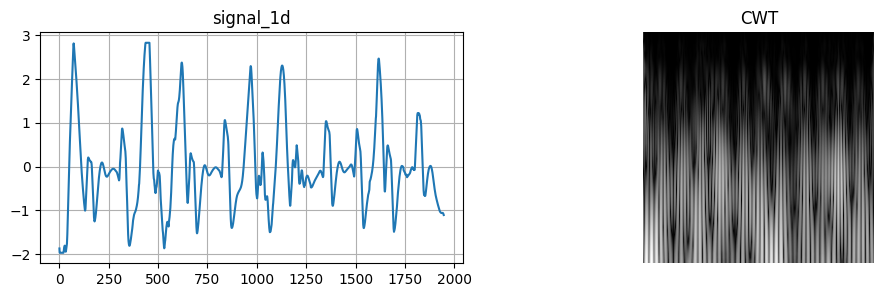

In [51]:
import random, matplotlib.pyplot as plt
from PIL import Image
import numpy as np

path, y = random.choice(items)
img = Image.open(path).convert("L")
sig = extract_ecg_from_image(img)
scal = generate_cwt_scalogram(sig, size=(IMG_SIZE, IMG_SIZE))

print("sig mean/std:", float(np.mean(sig)), float(np.std(sig)))
plt.figure(figsize=(12,3))
plt.subplot(1,2,1); plt.plot(sig); plt.title("signal_1d"); plt.grid(True)
plt.subplot(1,2,2); plt.imshow(scal, cmap="gray"); plt.title("CWT"); plt.axis("off")
plt.show()

🔍 Pre-Training Check

1️⃣ Checking basic configurations...
  ✓ BASE_DIR: C:\Users\LYG Y9000x\OneDrive\Desktop\proj
  ✓ DATA_ROOT: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\ecg_dataset\development
  ✓ SAVE_DIR: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\weights_from_images_binary
  ✓ OUT_DIR: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary
  ✓ DEVICE: cuda
  ✓ BATCH_SIZE: 16
  ✓ EPOCHS: 40
  ✓ LR: 0.0005
  ✓ CLASSES: ['normal_ecg_images', 'abnormal_heartbeat_ecg_images', 'myocardial_infarction_ecg_images', 'post_mi_history_ecg_images']

2️⃣ Checking data paths...
  ✓ DATA_ROOT exists: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\ecg_dataset\development
  ✓ normal_ecg_images: 280 images
  ✓ abnormal_heartbeat_ecg_images: 230 images
  ✓ myocardial_infarction_ecg_images: 238 images
  ✓ post_mi_history_ecg_images: 170 images

3️⃣ Checking model classes...
  ✓ DSRFromImages: defined
  ✓ EnhancedDSResSE: defined
  ✓ PureCNN: defined
  ✓ CNNLSTM: defined
  ✓ PureLSTM: defined

4️⃣ Checkin

✓ RAG prototypes initialized: torch.Size([200, 256])
✅ RAG initialization complete!



Epoch 01/40 | Train Loss: 0.1625 | Val Loss: 0.1640 | Val Acc: 0.3077 | Val Precision: 0.0000 | Val Recall: 0.0000 | Val SP: 1.0000 | Val F1: 0.0000 | Val ROC-AUC: 0.5241 | Val PR-AUC: 0.7362
✅ Saved best model to: Original_DSR_binary_best.pth


Epoch 02/40 | Train Loss: 0.1452 | Val Loss: 0.1353 | Val Acc: 0.5604 | Val Precision: 0.6885 | Val Recall: 0.6667 | Val SP: 0.3214 | Val F1: 0.6774 | Val ROC-AUC: 0.5726 | Val PR-AUC: 0.7727
✅ Saved best model to: Original_DSR_binary_best.pth


Epoch 03/40 | Train Loss: 0.1353 | Val Loss: 0.1728 | Val Acc: 0.3956 | Val Precision: 0.8333 | Val Recall: 0.1587 | Val SP: 0.9286 | Val F1: 0.2667 | Val ROC-AUC: 0.6239 | Val PR-AUC: 0.7989


...

Epoch 29/40 | Train Loss: 0.0001 | Val Loss: 0.2078 | Val Acc: 0.8901 | Val Precision: 0.9649 | Val Recall: 0.8730 | Val SP: 0.9286 | Val F1: 0.9167 | Val ROC-AUC: 0.9450 | Val PR-AUC: 0.9751


   [Monitor] Logits range: [-2.13, 2.01] ✓
Epoch 30/40 | Train Loss: 0.0001 | Val Loss: 0.2085 | Val Acc: 0.8901 | Val Precision: 0.9649 | Val Recall: 0.8730 | Val SP: 0.9286 | Val F1: 0.9167 | Val ROC-AUC: 0.9450 | Val PR-AUC: 0.9751


Epoch 31/40 | Train Loss: 0.0000 | Val Loss: 0.2158 | Val Acc: 0.8791 | Val Precision: 0.9643 | Val Recall: 0.8571 | Val SP: 0.9286 | Val F1: 0.9076 | Val ROC-AUC: 0.9442 | Val PR-AUC: 0.9748
Early stopping at epoch 31

Testing Pure_LSTM



Testing: 100%|██████████| 6/6 [00:03<00:00,  1.51it/s]



Pure_LSTM Test Results (Binary):
  Loss:        0.0000
  Accuracy:    0.8132
  Specificity: 0.7857
  Recall:      0.8254
  Precision:   0.8966
  F1:          0.8595
  ROC-AUC:     0.8929
  PR-AUC:      0.9536
  CM: 
[[22  6]
 [11 52]]

Training pipeline completed!



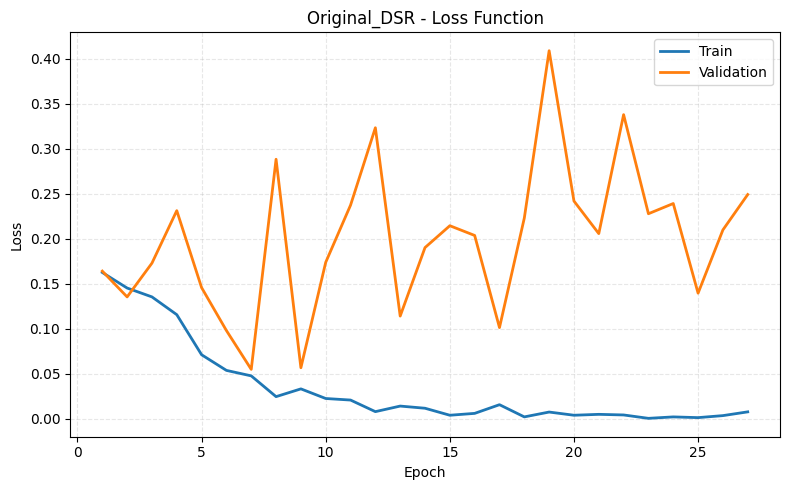

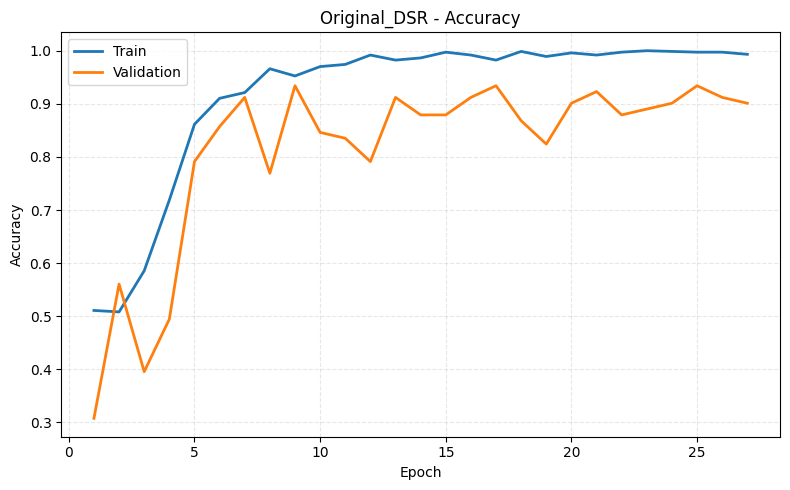

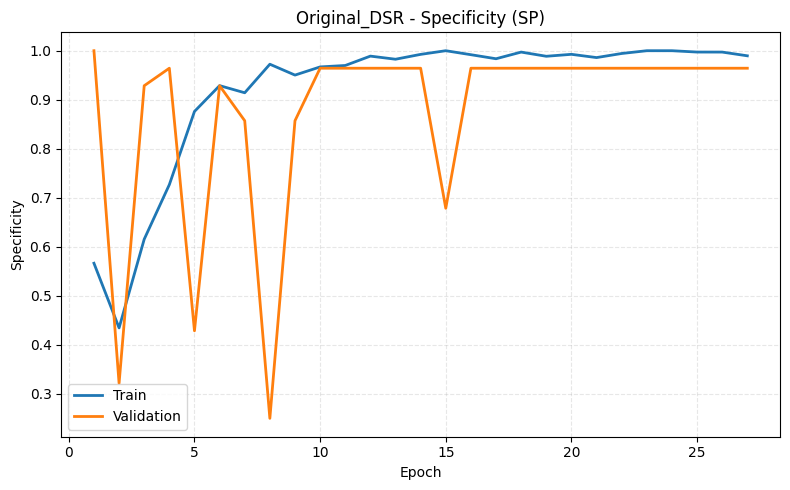

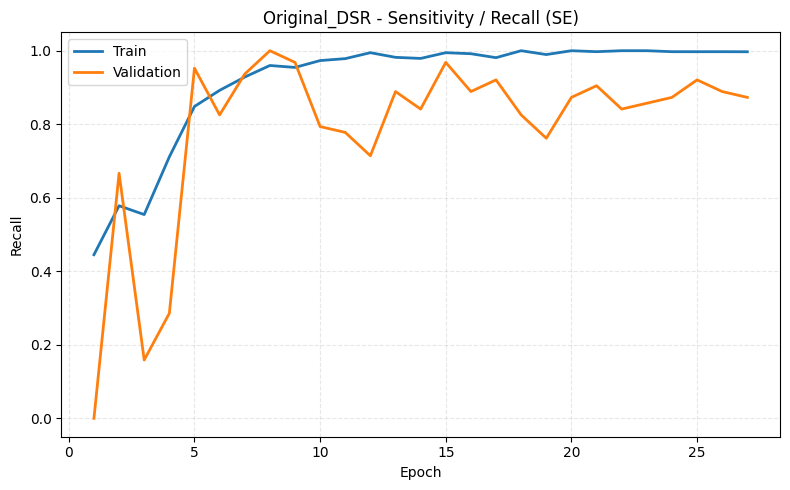

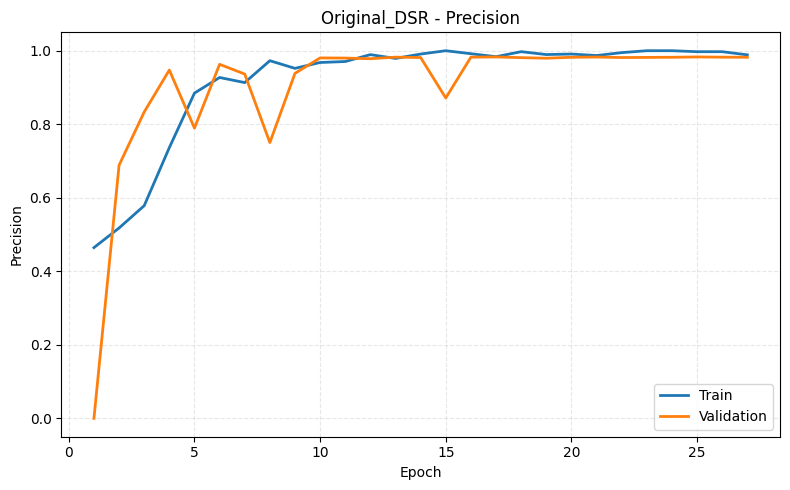

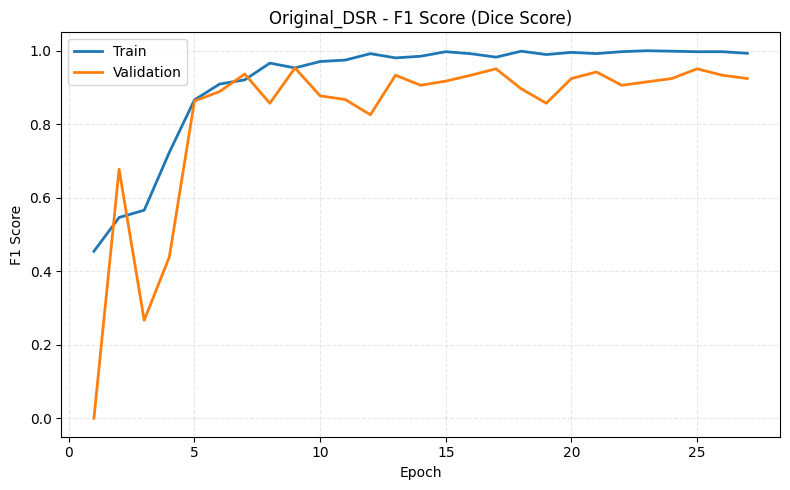

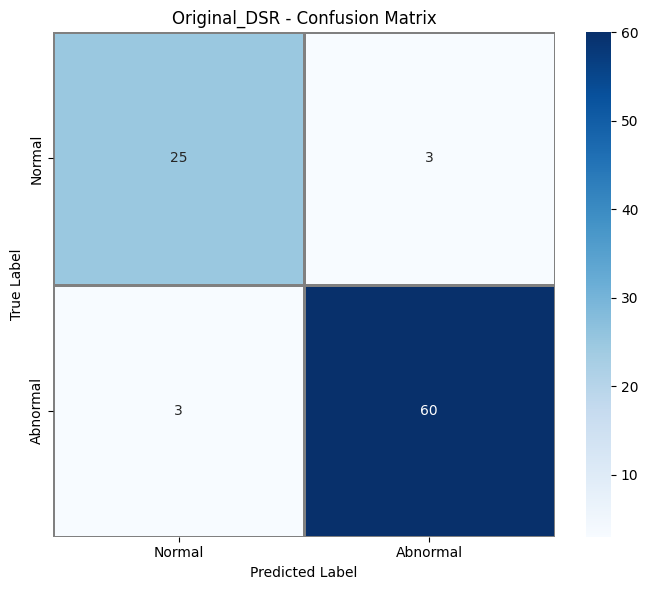

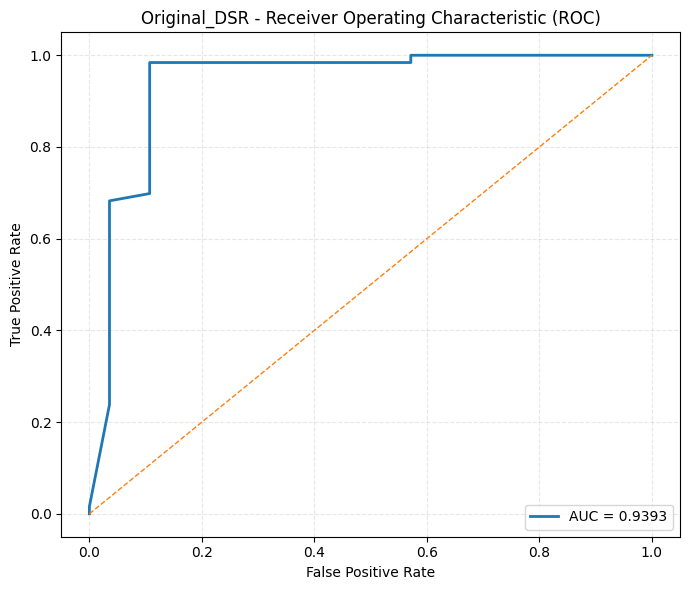

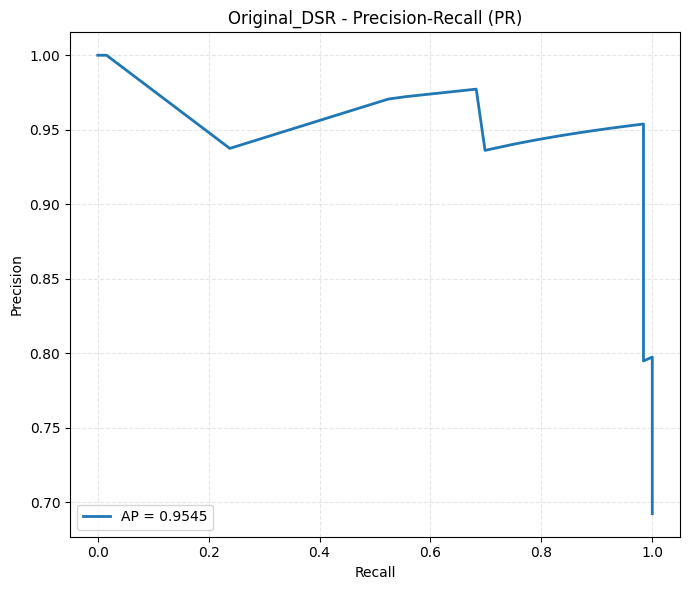

✓ All required figures saved for Original_DSR -> C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\test_figure\Original_DSR


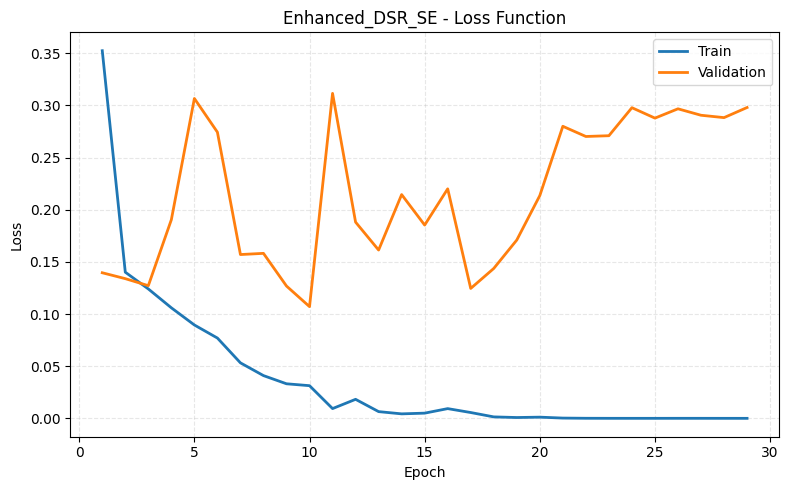

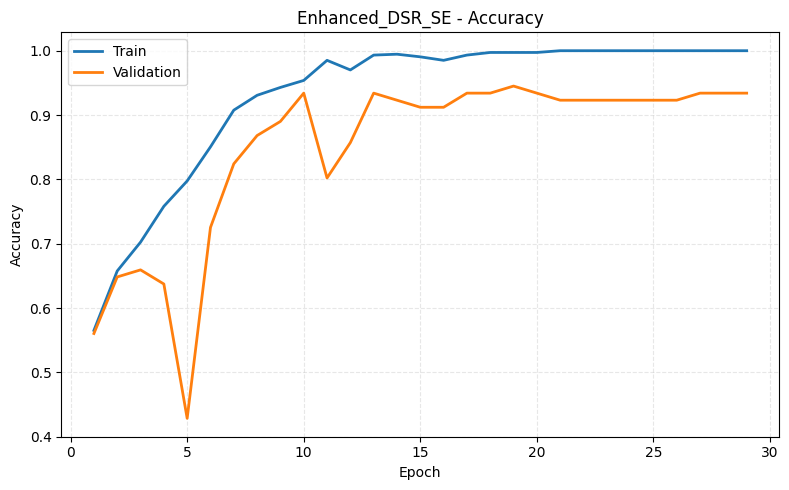

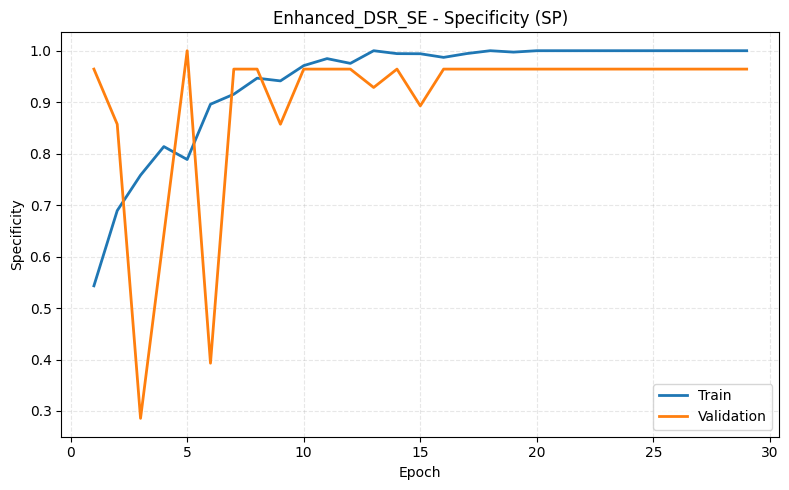

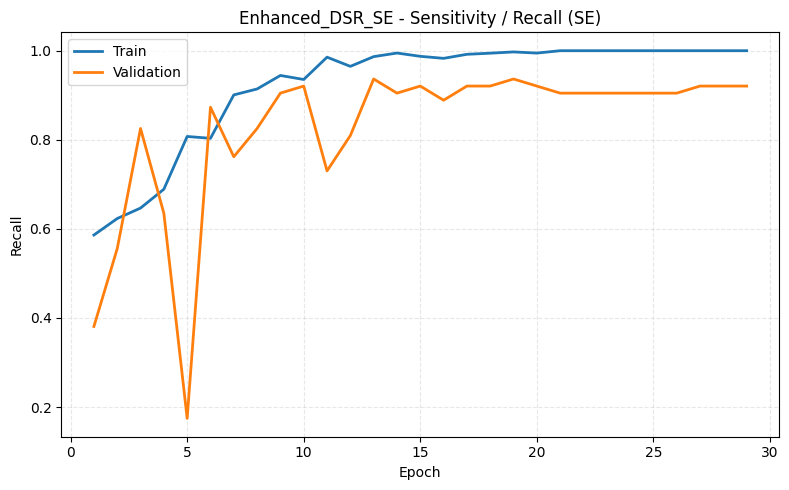

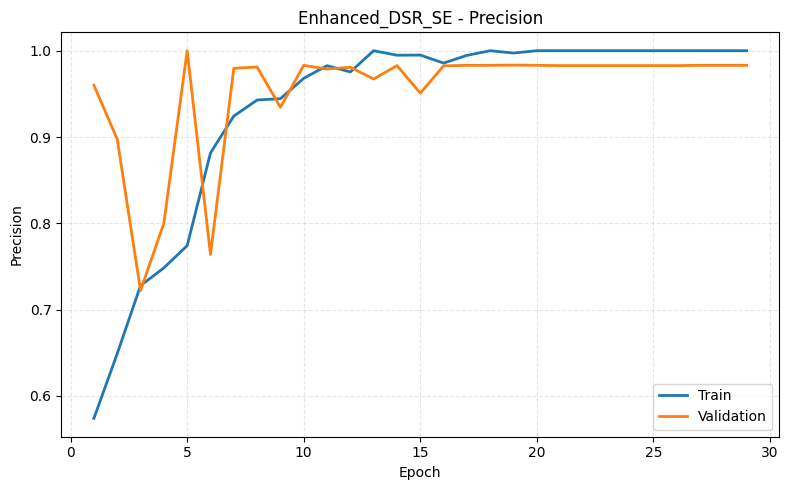

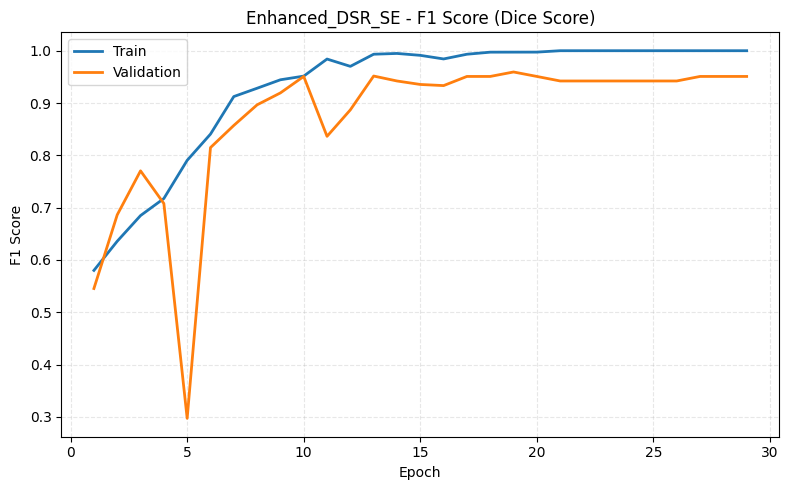

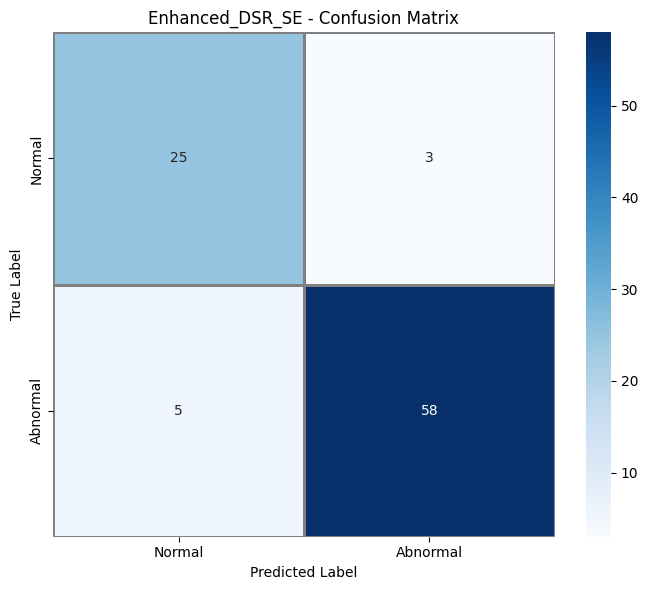

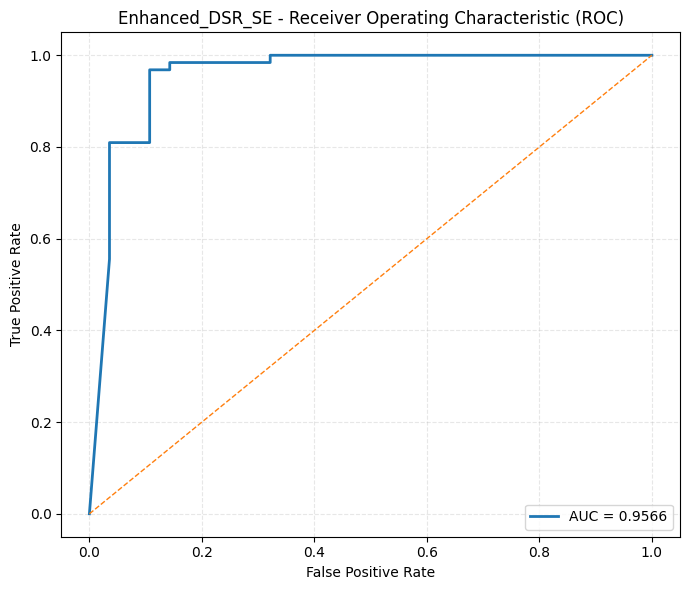

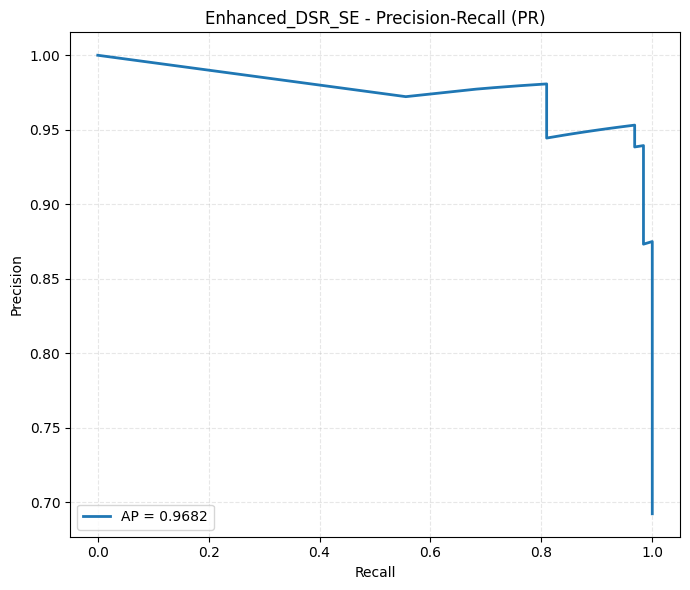

✓ All required figures saved for Enhanced_DSR_SE -> C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\test_figure\Enhanced_DSR_SE


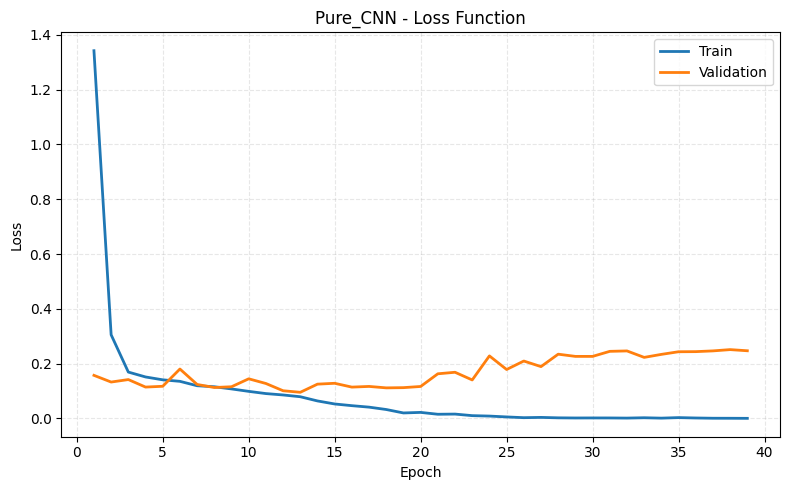

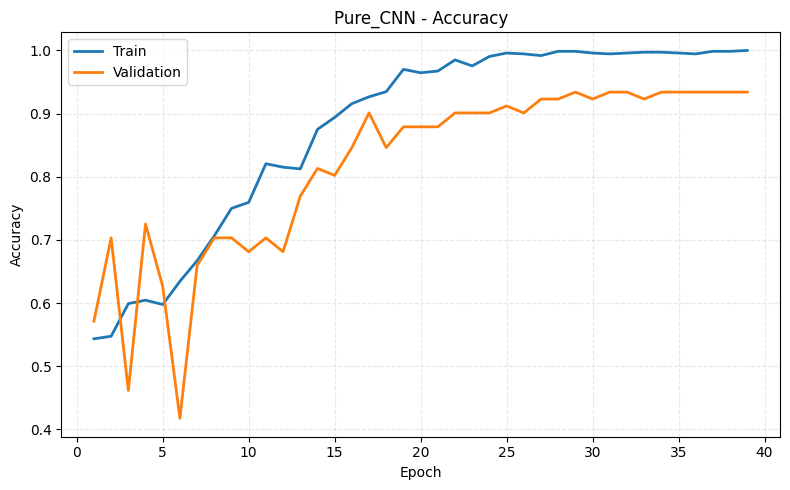

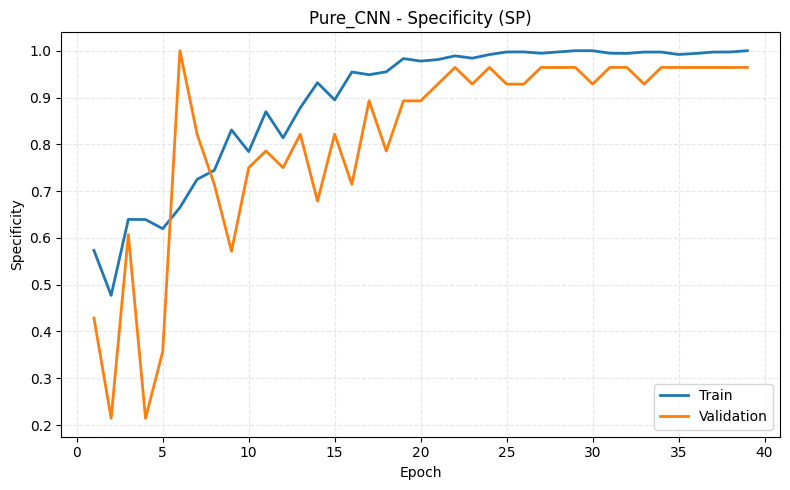

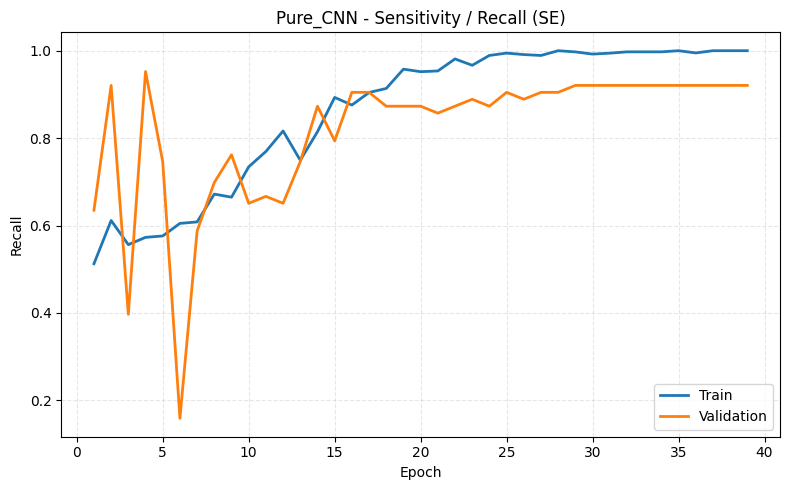

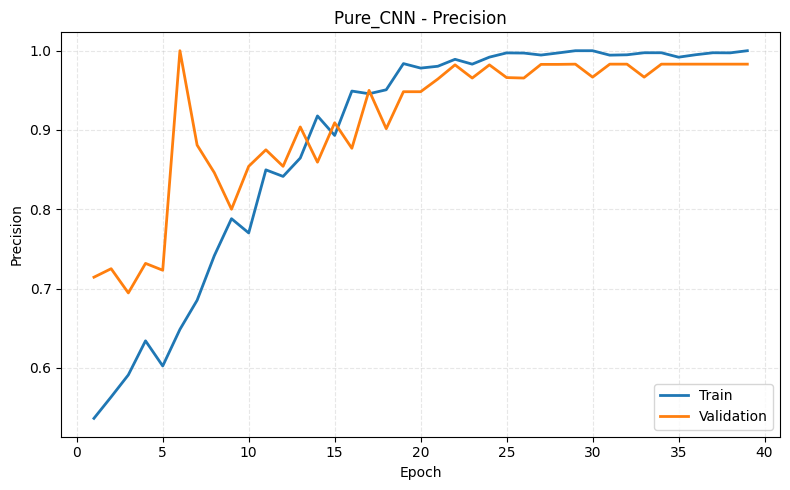

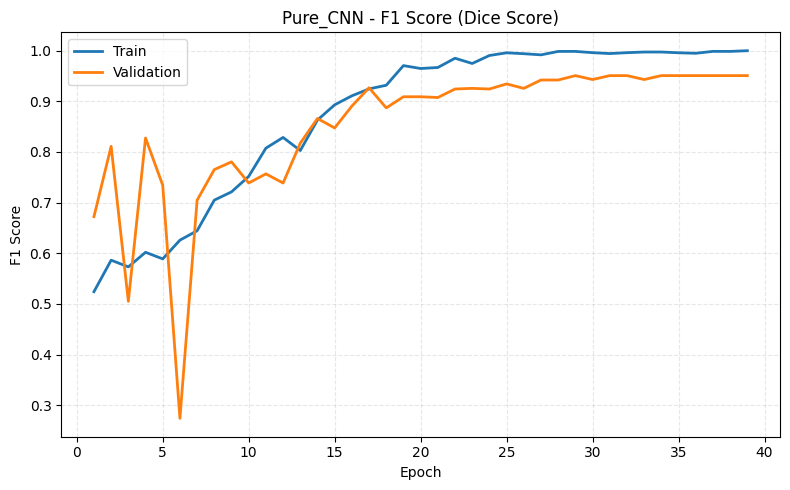

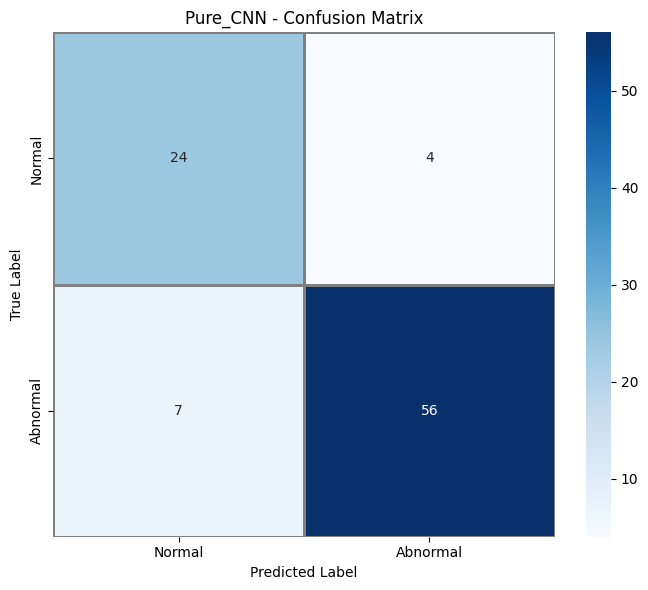

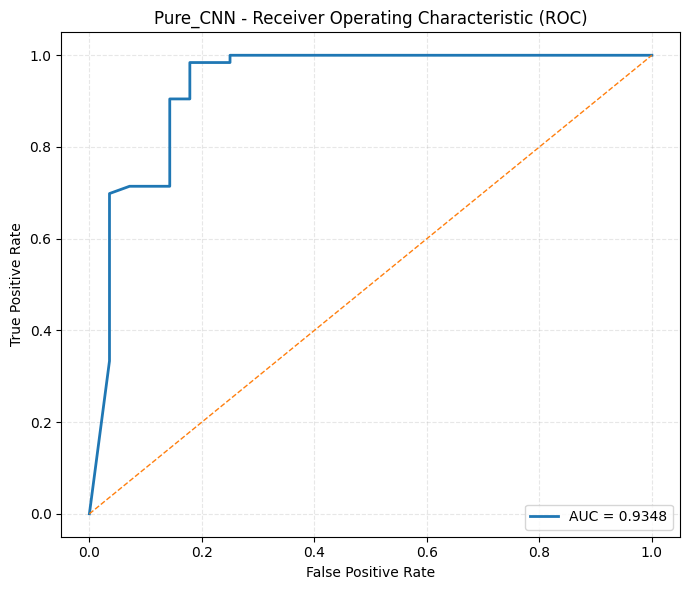

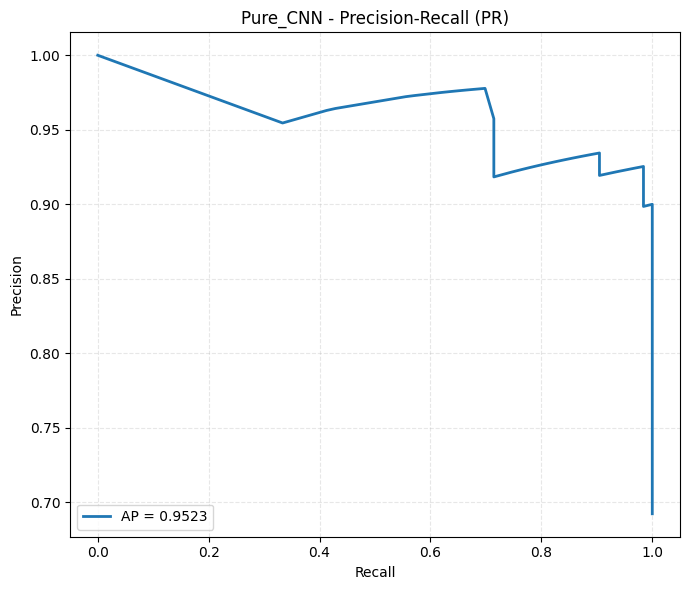

✓ All required figures saved for Pure_CNN -> C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\test_figure\Pure_CNN


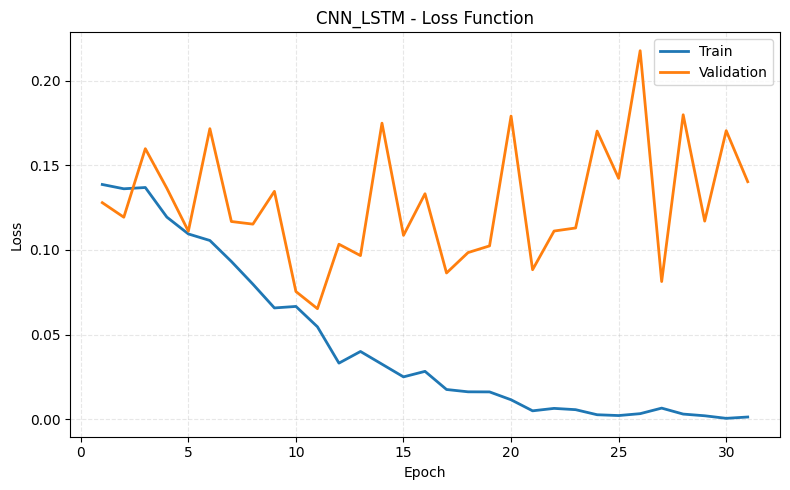

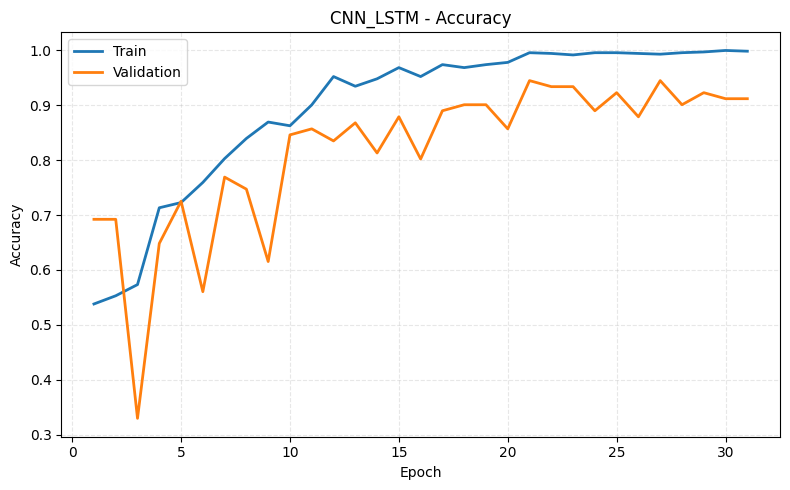

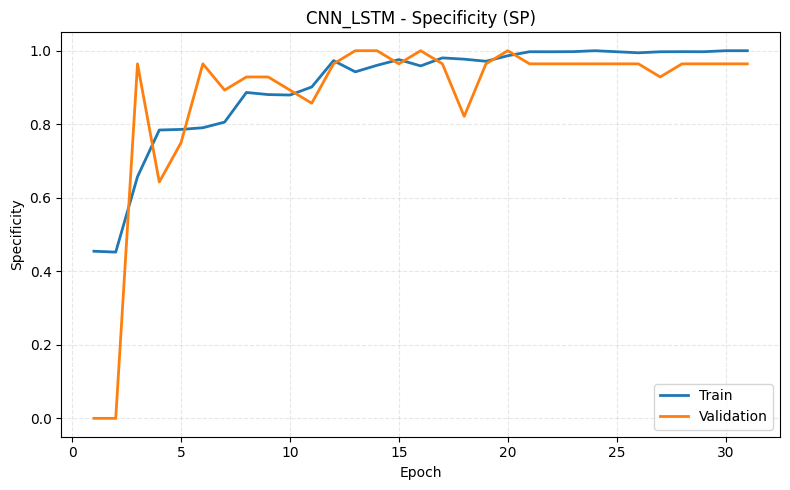

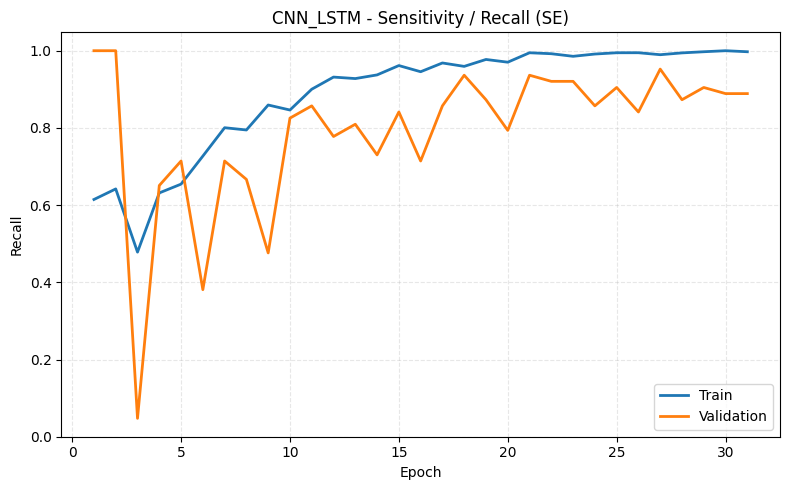

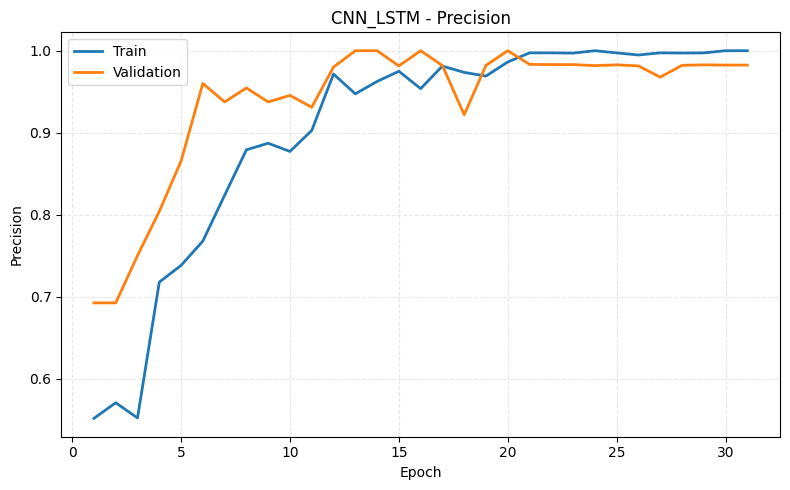

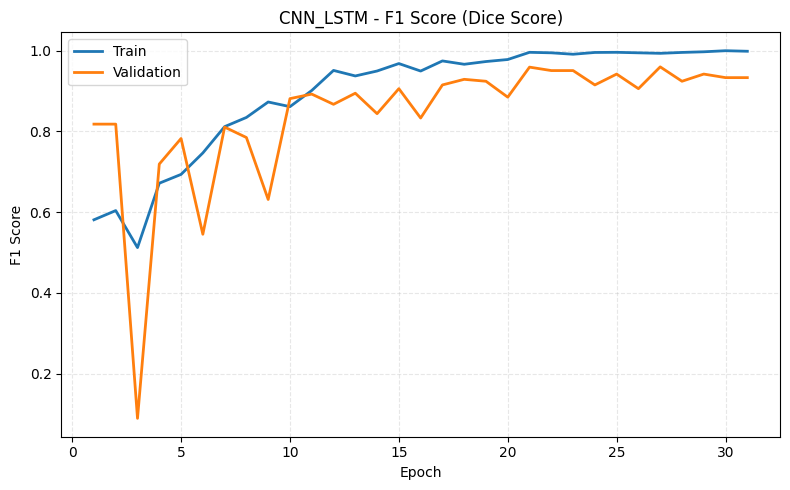

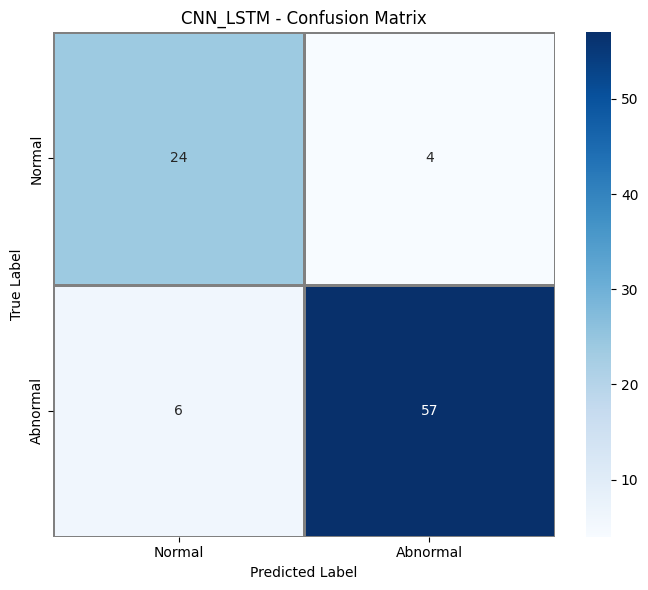

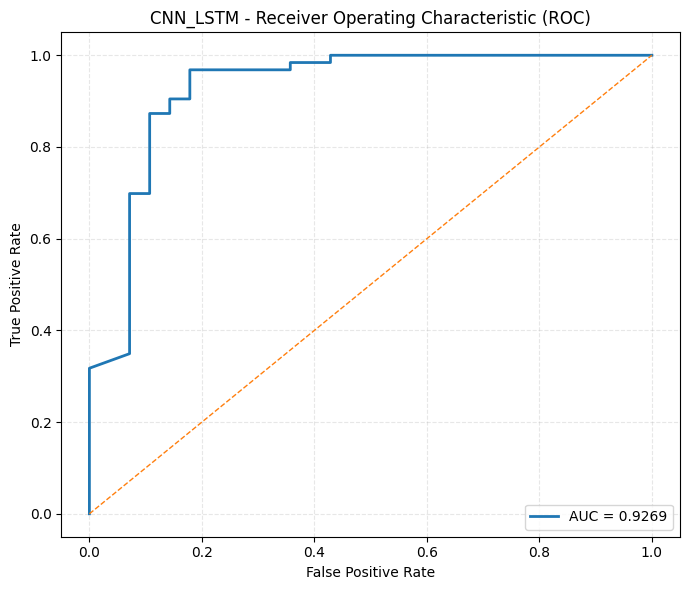

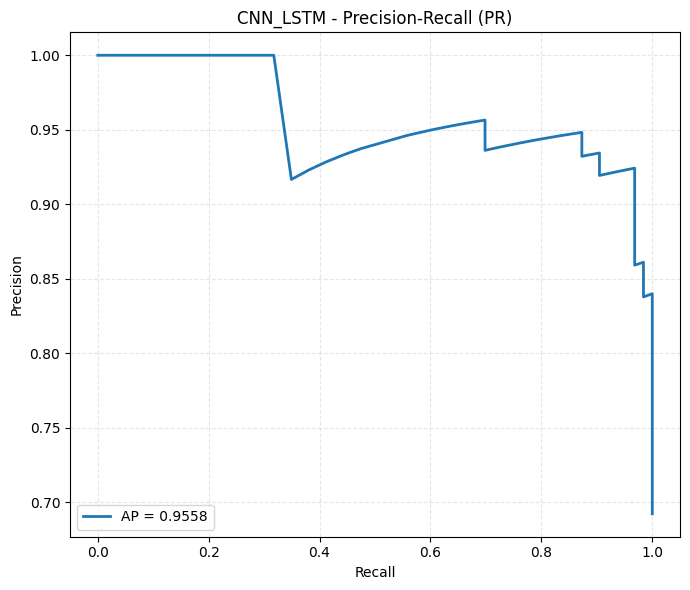

✓ All required figures saved for CNN_LSTM -> C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\test_figure\CNN_LSTM


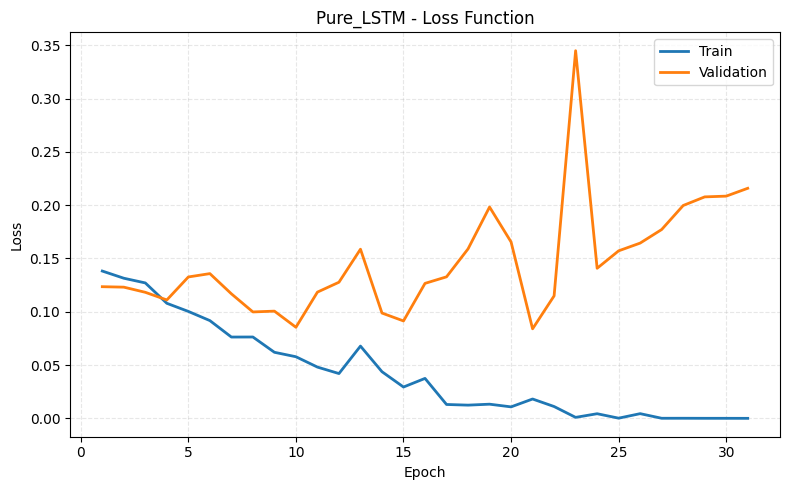

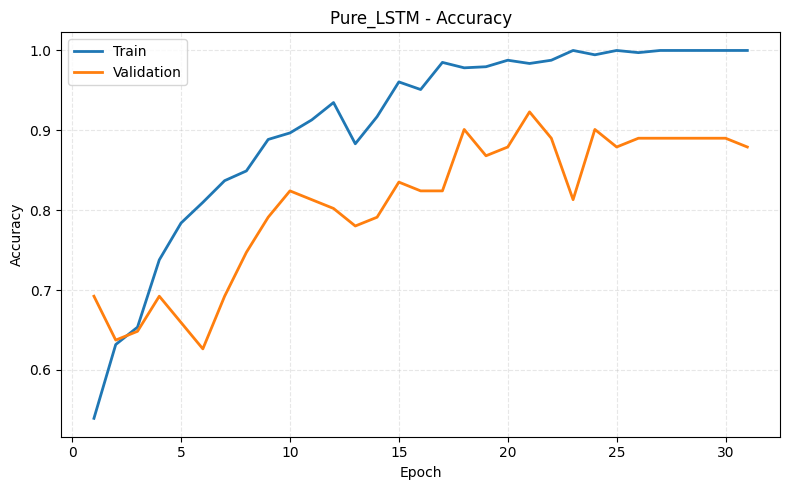

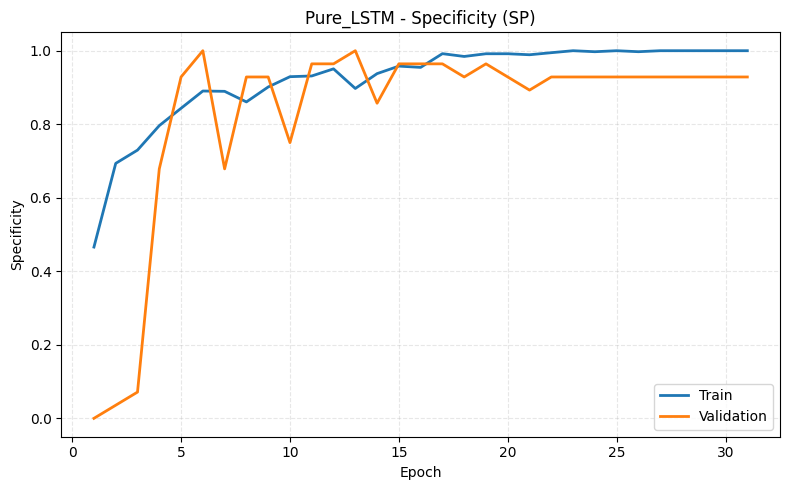

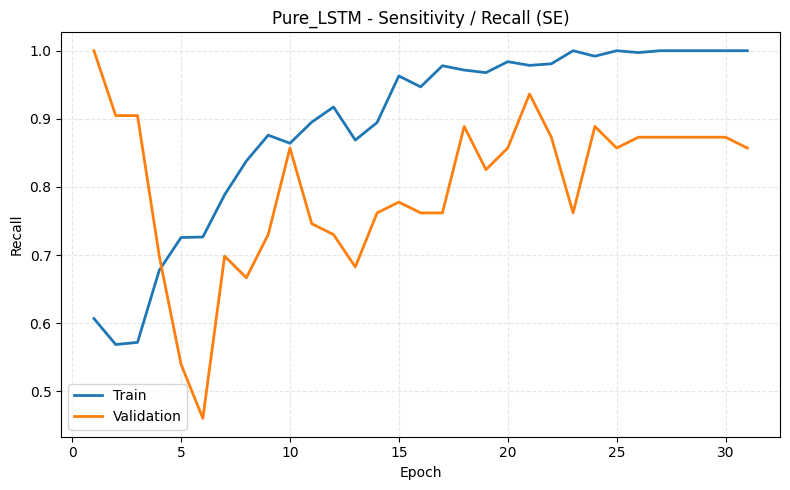

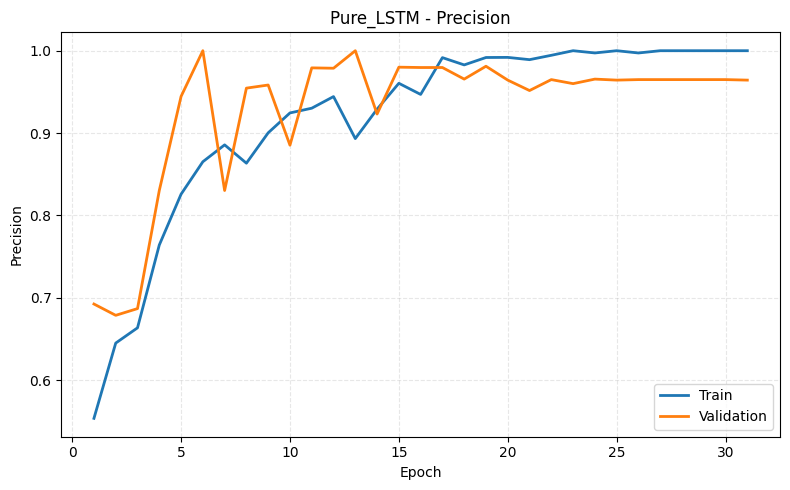

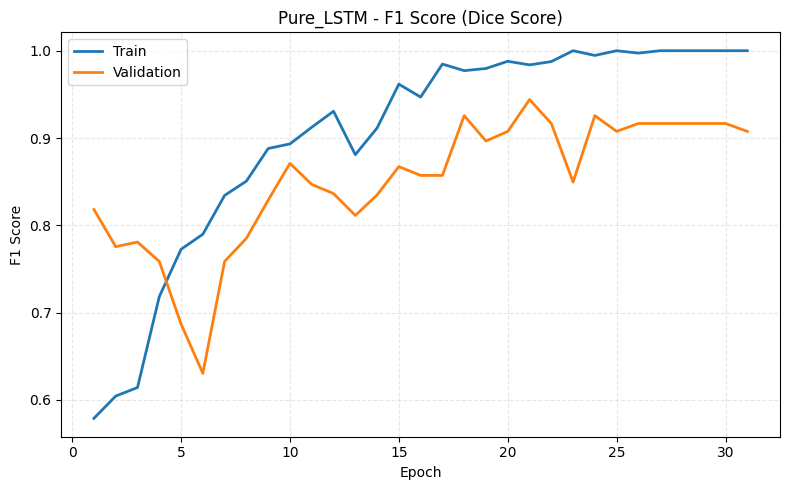

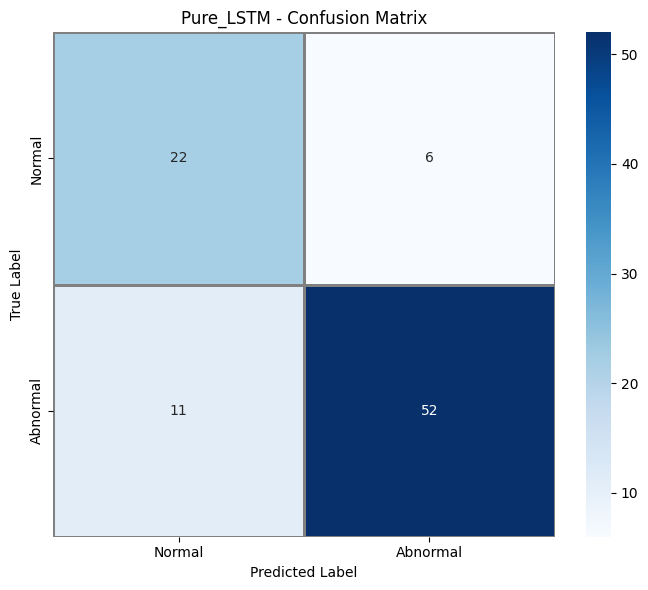

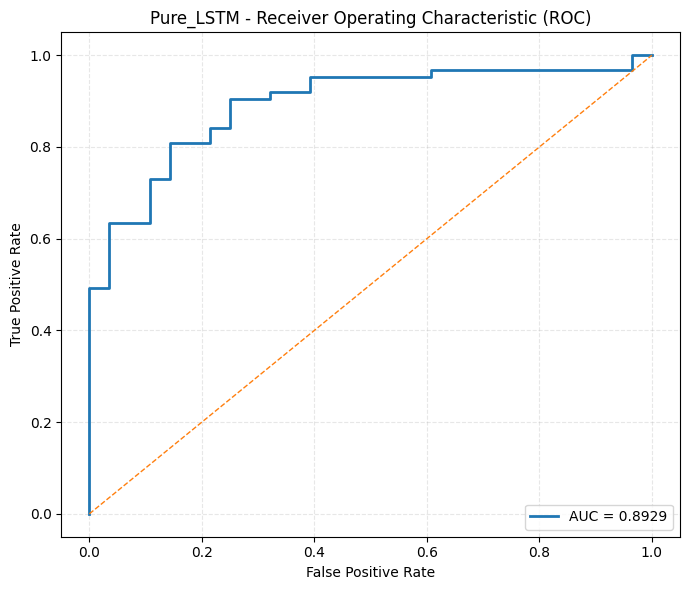

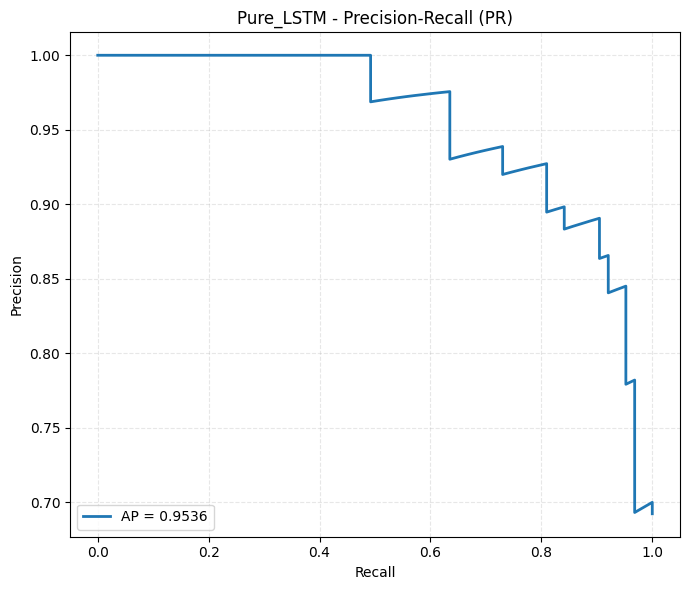

✓ All required figures saved for Pure_LSTM -> C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\test_figure\Pure_LSTM


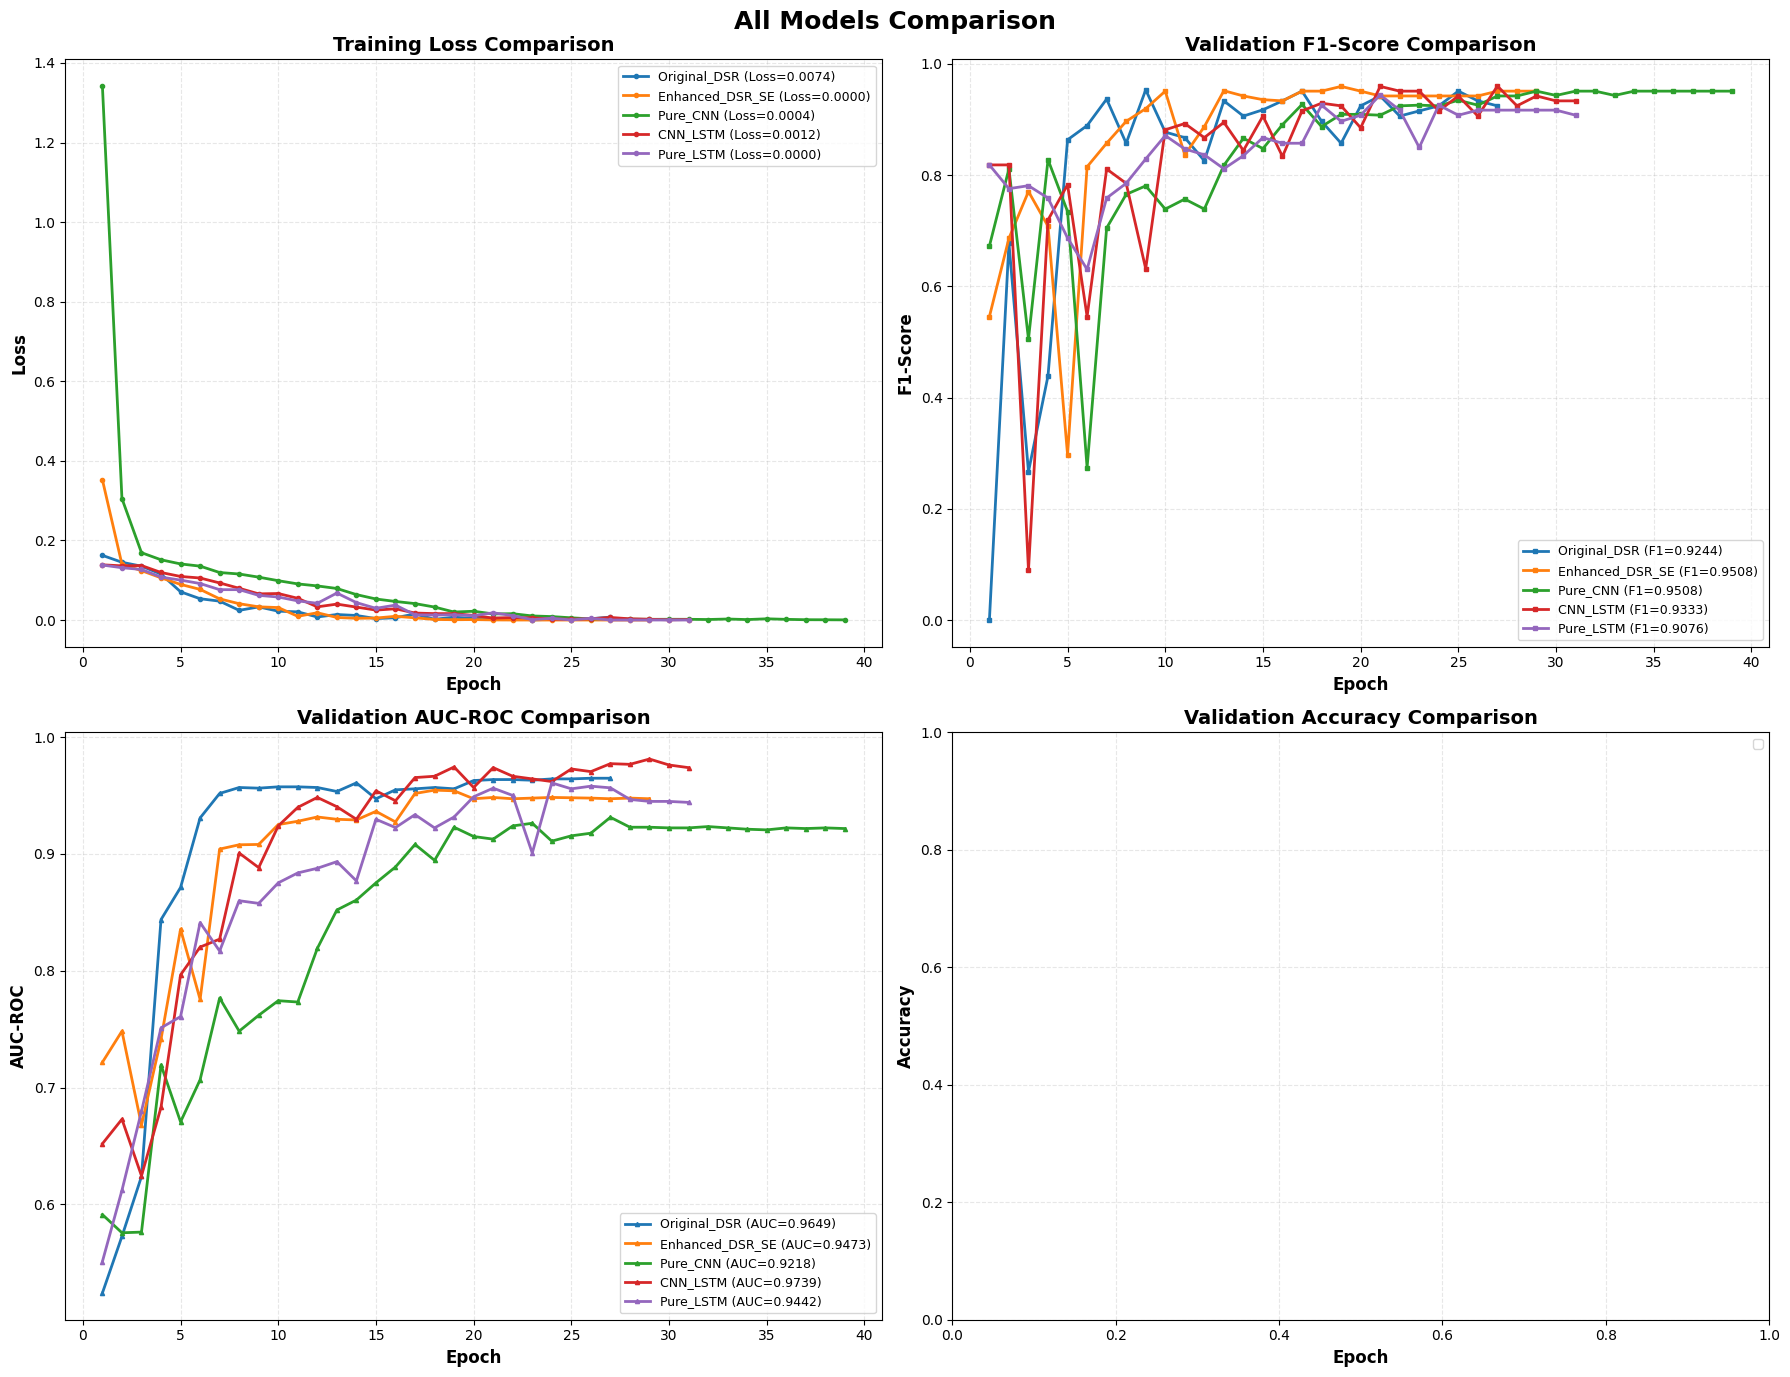

✓ Comparison plots saved

✅ Training and visualization complete!
📊 Plots saved to: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\test_figure


In [25]:
# 训练前先检查
if pre_training_check():
    print("\n" + "="*80)
    print("Starting training...")
    print("="*80 + "\n")
    
    # 定义模型配置
    model_configs_full = [
        (DSRFromImages, "Original_DSR"),
        (EnhancedDSResSE, "Enhanced_DSR_SE"),
        (PureCNN, "Pure_CNN"),
        (CNNLSTM, "CNN_LSTM"),
        (PureLSTM, "Pure_LSTM")
    ]
    
    # 训练所有模型
    results = train_and_compare_models(model_configs_full, use_kfold=False)
    
    # 绘图
    TEST_FIG_DIR = OUT_DIR / "test_figure"
    TEST_FIG_DIR.mkdir(parents=True, exist_ok=True)
    
    for model_name in results['histories'].keys():
        model_fig_dir = TEST_FIG_DIR / model_name
        model_fig_dir.mkdir(parents=True, exist_ok=True)

        plot_required_figures(
            model_name=model_name,
            history=results['histories'][model_name],
            test_metrics=results['test_metrics'][model_name],
            save_dir=model_fig_dir
        )
    
    plot_all_models_comparison(results, save_dir=TEST_FIG_DIR)
    
    print(f"\n✅ Training and visualization complete!")
    print(f"📊 Plots saved to: {TEST_FIG_DIR}")
else:
    print("\n❌ Pre-training check failed. Please fix the errors above.")


In [ ]:
# =========================
# Unified post-training plotting cell
# =========================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Optional fallback
# -------------------------
try:
    CLASS_NAMES
except NameError:
    CLASS_NAMES = ["Normal", "Abnormal"]

try:
    TEST_FIG_DIR
except NameError:
    TEST_FIG_DIR = Path("./test_figure")

TEST_FIG_DIR = Path(TEST_FIG_DIR)
TEST_FIG_DIR.mkdir(parents=True, exist_ok=True)


# -------------------------
# Helper functions
# -------------------------
def _get_first_valid(d, keys, default=None):
    for k in keys:
        if k in d and d[k] is not None:
            return d[k]
    return default


def _best_value_and_epoch(values, lower_is_better=False):
    if values is None or len(values) == 0:
        return 0.0, 0
    if lower_is_better:
        best_val = min(values)
    else:
        best_val = max(values)
    best_epoch = values.index(best_val) + 1
    return best_val, best_epoch


def plot_curve(history, train_key, val_key, title, ylabel, save_path):
    train_values = history.get(train_key, [])
    val_values = history.get(val_key, [])

    if len(train_values) == 0 or len(val_values) == 0:
        print(f"Skip {title}: missing {train_key} or {val_key}.")
        return

    epochs = range(1, len(train_values) + 1)
    lower_is_better = ("loss" in train_key.lower()) or ("loss" in val_key.lower())

    train_best, train_best_epoch = _best_value_and_epoch(train_values, lower_is_better)
    val_best, val_best_epoch = _best_value_and_epoch(val_values, lower_is_better)

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        train_values,
        linewidth=2,
        label=f"Train best={train_best:.4f} (epoch {train_best_epoch})"
    )
    plt.plot(
        epochs,
        val_values,
        linewidth=2,
        label=f"Validation best={val_best:.4f} (epoch {val_best_epoch})"
    )

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(
        f"{title}\n"
        f"Train best={train_best:.4f} @ epoch {train_best_epoch}, "
        f"Val best={val_best:.4f} @ epoch {val_best_epoch}"
    )
    plt.grid(True, alpha=0.3, linestyle="--")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_confusion_matrix(cm, class_names, title, save_path, metrics_text=None):
    if cm is None:
        print(f"Skip {title}: confusion matrix not found.")
        return

    cm = np.array(cm)
    total = cm.sum()
    cm_percent = (cm / total * 100.0) if total > 0 else np.zeros_like(cm, dtype=float)

    annot = np.empty_like(cm).astype(object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n({cm_percent[i, j]:.2f}%)"

    plt.figure(figsize=(7.5, 6.5))
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=1,
        linecolor="gray",
        cbar=True
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    if metrics_text is not None and len(metrics_text) > 0:
        plt.title(f"{title}\n{metrics_text}")
    else:
        plt.title(title)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_roc_curve(fpr, tpr, roc_auc, title, save_path):
    if fpr is None or tpr is None:
        print(f"Skip {title}: ROC data not found.")
        return

    plt.figure(figsize=(7, 6))
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"ROC curve (ROC-AUC = {roc_auc:.4f})"
    )
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
        label="Random baseline"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title}\nROC-AUC = {roc_auc:.4f}")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_pr_curve(pr_recall, pr_precision, pr_auc, title, save_path):
    if pr_recall is None or pr_precision is None:
        print(f"Skip {title}: PR data not found.")
        return

    plt.figure(figsize=(7, 6))
    plt.plot(
        pr_recall,
        pr_precision,
        linewidth=2,
        label=f"PR curve (PR-AUC = {pr_auc:.4f})"
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title}\nPR-AUC = {pr_auc:.4f}")
    plt.legend(loc="lower left")
    plt.grid(True, alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_required_figures(model_name, history, test_metrics, save_dir):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    # ---- Read metrics safely ----
    cm = _get_first_valid(test_metrics, ["confusion_matrix", "cm"])
    accuracy = _get_first_valid(test_metrics, ["accuracy", "oa"], 0.0)
    precision = _get_first_valid(test_metrics, ["precision"], 0.0)
    recall = _get_first_valid(test_metrics, ["recall", "sensitivity"], 0.0)
    specificity = _get_first_valid(test_metrics, ["specificity"], 0.0)
    f1 = _get_first_valid(test_metrics, ["f1", "macro_f1"], 0.0)
    roc_auc = _get_first_valid(test_metrics, ["roc_auc", "macro_auc"], 0.0)
    pr_auc = _get_first_valid(test_metrics, ["pr_auc"], 0.0)

    fpr = _get_first_valid(test_metrics, ["fpr"])
    tpr = _get_first_valid(test_metrics, ["tpr"])
    pr_precision = _get_first_valid(test_metrics, ["pr_precision"])
    pr_recall = _get_first_valid(test_metrics, ["pr_recall"])

    # ---- Curve plots ----
    plot_curve(
        history, "train_loss", "val_loss",
        f"{model_name} - Loss Function",
        "Loss",
        save_dir / f"{model_name}_loss.png"
    )

    plot_curve(
        history, "train_acc", "val_acc",
        f"{model_name} - Accuracy",
        "Accuracy",
        save_dir / f"{model_name}_accuracy.png"
    )

    plot_curve(
        history, "train_specificity", "val_specificity",
        f"{model_name} - Specificity (SP)",
        "Specificity",
        save_dir / f"{model_name}_specificity.png"
    )

    plot_curve(
        history, "train_recall", "val_recall",
        f"{model_name} - Sensitivity / Recall (SE)",
        "Recall",
        save_dir / f"{model_name}_recall.png"
    )

    plot_curve(
        history, "train_precision", "val_precision",
        f"{model_name} - Precision",
        "Precision",
        save_dir / f"{model_name}_precision.png"
    )

    plot_curve(
        history, "train_f1", "val_f1",
        f"{model_name} - F1 Score",
        "F1 Score",
        save_dir / f"{model_name}_f1.png"
    )

    # ---- Confusion matrix ----
    metrics_text = (
        f"Acc={accuracy:.4f} | Prec={precision:.4f} | Recall={recall:.4f} | "
        f"Spec={specificity:.4f} | F1={f1:.4f} | ROC-AUC={roc_auc:.4f} | PR-AUC={pr_auc:.4f}"
    )

    plot_confusion_matrix(
        cm=cm,
        class_names=CLASS_NAMES,
        title=f"{model_name} - Confusion Matrix",
        save_path=save_dir / f"{model_name}_confusion_matrix.png",
        metrics_text=metrics_text
    )

    # ---- ROC ----
    plot_roc_curve(
        fpr=fpr,
        tpr=tpr,
        roc_auc=roc_auc,
        title=f"{model_name} - Receiver Operating Characteristic (ROC)",
        save_path=save_dir / f"{model_name}_roc.png"
    )

    # ---- PR ----
    plot_pr_curve(
        pr_recall=pr_recall,
        pr_precision=pr_precision,
        pr_auc=pr_auc,
        title=f"{model_name} - Precision-Recall (PR)",
        save_path=save_dir / f"{model_name}_pr.png"
    )

    print(f"✓ All figures saved for {model_name} -> {save_dir}")


# -------------------------
# Main execution
# -------------------------
if "results" not in globals():
    raise ValueError("`results` not found. Please make sure you have already finished training and `results` exists.")

if "histories" not in results or "test_metrics" not in results:
    raise ValueError("`results` does not contain `histories` or `test_metrics`.")

for model_name in results["histories"].keys():
    model_fig_dir = TEST_FIG_DIR / model_name
    model_fig_dir.mkdir(parents=True, exist_ok=True)

    plot_required_figures(
        model_name=model_name,
        history=results["histories"][model_name],
        test_metrics=results["test_metrics"][model_name],
        save_dir=model_fig_dir
    )

print(f"\n✓ All plotting finished. Figures are saved under: {TEST_FIG_DIR}")

ValueError: `results` not found. Please make sure you have already finished training and `results` exists.

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def integrated_gradients_simple(model, input_img, rr_data, target_class, steps=30):
    """简化版IG"""
    baseline = torch.zeros_like(input_img)
    alphas = torch.linspace(0, 1, steps).to(input_img.device)
    gradients = []
    
    model.train()
    
    for alpha in alphas:
        interpolated = baseline + alpha * (input_img - baseline)
        interpolated.requires_grad = True
        
        output = model(interpolated, rr_data)
        score = output[0, target_class]
    
        score.backward()
        
        gradients.append(interpolated.grad.detach().cpu())
    
    model.eval()
    
    avg_gradients = torch.stack(gradients).mean(dim=0)
    integrated_grads = (input_img.cpu() - baseline.cpu()) * avg_gradients
    
    return integrated_grads


def explain_model_simple(model, model_name, test_loader, save_dir=None, num_samples=20):
    """
    简化版可解释性分析（使用训练时的数据）
    """
    if save_dir:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"\n{'='*80}")
    print(f"🔍 Explainability for {model_name}")
    print(f"{'='*80}\n")
    
    # 直接使用test_loader的数据（CWT scalogram）
    all_images = []
    all_rr = []
    all_labels = []
    
    for imgs, rr, labels, _ in test_loader:
        all_images.append(imgs)
        all_rr.append(rr)
        all_labels.append(labels)
        if len(all_images) * imgs.shape[0] >= num_samples:
            break
    
    images = torch.cat(all_images, dim=0)[:num_samples]
    rr_data = torch.cat(all_rr, dim=0)[:num_samples]
    labels = torch.cat(all_labels, dim=0)[:num_samples].numpy()
    
    # 为每个类别选择样本
    class_samples = {}
    for idx, label in enumerate(labels):
        if label not in class_samples:
            class_samples[label] = idx
        if len(class_samples) == 4:
            break
    
    print(f"  Analyzing {len(class_samples)} samples...")
    
    # 生成可视化
    fig, axes = plt.subplots(len(class_samples), 3, figsize=(15, 4*len(class_samples)))
    if len(class_samples) == 1:
        axes = axes.reshape(1, -1)
    
    for row_idx, (class_idx, sample_idx) in enumerate(class_samples.items()):
        img = images[sample_idx:sample_idx+1].to(DEVICE)
        rr = rr_data[sample_idx:sample_idx+1].to(DEVICE)
        
        print(f"  Computing for {CLASS_NAMES[class_idx]}...")
        
        try:
            # 计算IG
            attributions = integrated_gradients_simple(
                model, img, rr, 
                target_class=class_idx, 
                steps=50  # 增加步数提高平滑度
            )
            
            attr_np = attributions.squeeze().numpy()
            
            if len(attr_np.shape) == 3:
                attr_map = np.abs(attr_np[0])
            else:
                attr_map = np.abs(attr_np)
            
            # 🔑 强力平滑去噪
            from scipy.ndimage import gaussian_filter
            attr_map = gaussian_filter(attr_map, sigma=3)  # 高斯平滑
            
            # 百分位数归一化
            p10, p90 = np.percentile(attr_map, [10, 90])
            attr_map = np.clip(attr_map, p10, p90)
            attr_map = (attr_map - attr_map.min()) / (attr_map.max() - attr_map.min() + 1e-8)
            
        except Exception as e:
            print(f"  ⚠️ Error: {e}")
            continue
        
        # 原始scalogram
        ax = axes[row_idx, 0]
        img_np = img.squeeze().cpu().numpy()
        ax.imshow(img_np, cmap='gray')
        ax.set_title(f'Input: {CLASS_NAMES[class_idx]}', fontsize=12, fontweight='bold')
        ax.axis('off')
        

        ax = axes[row_idx, 1]
        im = ax.imshow(attr_map, cmap='jet', vmin=0, vmax=1)
        ax.set_title(f'Important Regions', fontsize=12, fontweight='bold')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)
        
        # 叠加图
        ax = axes[row_idx, 2]
        ax.imshow(img_np, cmap='gray', alpha=0.6)
        ax.imshow(attr_map, cmap='hot', alpha=0.5)
        ax.set_title('Model Focus', fontsize=12, fontweight='bold')
        ax.axis('off')
    
    plt.suptitle(f'{model_name} - Explainability Analysis', 
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_dir:
        plt.savefig(save_dir / f'{model_name}_explanation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Complete for {model_name}\n")


print("✓ Simplified explainability function loaded")


✓ Simplified explainability function loaded


In [ ]:

EXPLAIN_DIR = OUT_DIR / "explanations_final"
EXPLAIN_DIR.mkdir(parents=True, exist_ok=True)

_, _, L_te, _ = make_loaders()

for model_name in ['Original_DSR', 'Enhanced_DSR_SE', 'Pure_CNN', 'CNN_LSTM', 'Pure_LSTM']:
    explain_model_simple(
        model=results['models'][model_name],
        model_name=model_name,
        test_loader=L_te,
        save_dir=EXPLAIN_DIR,
        num_samples=20
    )

print(f"\n✅ All explanations saved to {EXPLAIN_DIR}")


📂 Class folders detected - auto-splitting 80/10/10 (train/val/test)
✅ Auto split complete (80/10/10):
   Train: 736 samples
   Val:   91 samples
   Test:  91 samples
Binary train class counts:
  Normal: 224
  Abnormal: 512


NameError: name 'results' is not defined

In [54]:
import json
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path
from sklearn.metrics import f1_score, confusion_matrix

# 1) 先拿到你的验证集 loader（make_loaders 返回 L_tr, L_va, L_te, rr_dim）
L_tr, L_va, L_te, rr_dim_from_loader = make_loaders()

# 2) Model zoo（你之前 NameError 就是少了这个）
MODEL_ZOO = {
    "Original_DSR": DSRFromImages,
    "Enhanced_DSR_SE": EnhancedDSResSE,
    "Pure_CNN": PureCNN,
    "CNN_LSTM": CNNLSTM,
    "Pure_LSTM": PureLSTM,
    "Original_DSR_Attn_Proto": DSRFromImages,
}


WEIGHTS_DIR = Path(r"C:\Users\LYG Y9000x\OneDrive\Desktop\proj\weights_from_images_binary")
CKPTS = {
    "Original_DSR":    WEIGHTS_DIR / "Original_DSR_binary_best.pth",
    "Enhanced_DSR_SE": WEIGHTS_DIR / "Enhanced_DSR_SE_binary_best.pth",
    "Pure_CNN":        WEIGHTS_DIR / "Pure_CNN_binary_best.pth",
    "CNN_LSTM":        WEIGHTS_DIR / "CNN_LSTM_binary_best.pth",
    "Pure_LSTM":       WEIGHTS_DIR / "Pure_LSTM_binary_best.pth",
    "Original_DSR_Attn_Proto": WEIGHTS_DIR / "Original_DSR_Attn_Proto_best.pth",
}

def load_state(ckpt_path: Path):
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        return ckpt["model_state_dict"]
    return ckpt

def infer_use_rag_from_state(state_dict):
    return any(k.startswith("rag.") for k in state_dict.keys())

def infer_rr_dim_from_state(state_dict):
    # 如果 rrnet.* 存在，多半训练时 rr_dim>0；但你现在 rr_dim=0 也可能有 rrnet 参数
    # 最稳：用 loader 的 rr_dim（因为这就是训练时的数据输入维度）
    return int(rr_dim_from_loader)

def get_val_probs(model, state_dict, val_loader, device):
    model.load_state_dict(state_dict, strict=False)
    model.to(device)
    model.eval()

    ys, ps = [], []
    with torch.no_grad():
        for imgs, rr, labels, rel in val_loader:
            imgs = imgs.to(device)
            rr = rr.to(device)
            logits = model(imgs, rr)
            prob_abn = F.softmax(logits.float(), dim=1)[:, 1]  # p_abnormal
            ys.append(labels.cpu().numpy())
            ps.append(prob_abn.cpu().numpy())
    return np.concatenate(ys), np.concatenate(ps)

def find_best_threshold(y_true, p_abn):
    ts = np.linspace(0.05, 0.95, 181)
    best_t, best_f1, best_cm = 0.5, -1, None
    for t in ts:
        y_pred = (p_abn >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = float(t)
            best_cm = confusion_matrix(y_true, y_pred)
    return best_t, best_f1, best_cm

THR_MAP = {}

for name, ckpt_path in CKPTS.items():
    assert ckpt_path.exists(), f"Missing checkpoint: {ckpt_path}"

    state = load_state(ckpt_path)
    use_rag = infer_use_rag_from_state(state)
    rr_dim = infer_rr_dim_from_state(state)

    model = MODEL_ZOO[name](num_classes=2, rr_dim=rr_dim, use_rag=use_rag)
    y_true, p_abn = get_val_probs(model, state, L_va, DEVICE)
    best_t, best_f1, best_cm = find_best_threshold(y_true, p_abn)

    THR_MAP[name] = best_t
    print(f"{name}: best_t={best_t:.3f} | best_val_f1={best_f1:.4f}")
    print("CM:\n", best_cm)

out_path = WEIGHTS_DIR / "THR_MAP.json"
out_path.write_text(json.dumps(THR_MAP, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved:", out_path)

📂 Class folders detected - auto-splitting 80/10/10 (train/val/test)
✅ Auto split complete (80/10/10):
   Train: 736 samples
   Val:   91 samples
   Test:  91 samples
Binary train class counts:
  Normal: 224
  Abnormal: 512
✓ DSRFromImages with Self-Attention + RAG enabled
Original_DSR: best_t=0.300 | best_val_f1=0.9593
CM:
 [[27  1]
 [ 4 59]]
Enhanced_DSR_SE: best_t=0.155 | best_val_f1=0.9683
CM:
 [[26  2]
 [ 2 61]]
Pure_CNN: best_t=0.285 | best_val_f1=0.9508
CM:
 [[27  1]
 [ 5 58]]
CNN_LSTM: best_t=0.155 | best_val_f1=0.9606
CM:
 [[25  3]
 [ 2 61]]
Pure_LSTM: best_t=0.440 | best_val_f1=0.9440
CM:
 [[25  3]
 [ 4 59]]
✓ DSRFromImages with Self-Attention + RAG enabled
Original_DSR_Attn_Proto: best_t=0.050 | best_val_f1=0.8182
CM:
 [[ 0 28]
 [ 0 63]]
Saved: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\weights_from_images_binary\THR_MAP.json


## RAG

In [55]:
import torch
from pathlib import Path

def load_state(ckpt_path, map_location=None):
    """
    兼容：
    1) torch.save(model.state_dict(), path)
    2) torch.save({'model_state_dict': ..., ...}, path)
    3) 旧 checkpoint / 含 numpy scalar 的 checkpoint
    """
    ckpt_path = str(ckpt_path)

    try:
        obj = torch.load(
            ckpt_path,
            map_location=map_location or DEVICE,
            weights_only=True
        )
    except Exception as e:
        print("weights_only=True failed, fallback to weights_only=False")
        print("reason:", e)

        obj = torch.load(
            ckpt_path,
            map_location=map_location or DEVICE,
            weights_only=False
        )

    if isinstance(obj, dict):
        if "model_state_dict" in obj:
            return obj["model_state_dict"]
        if "state_dict" in obj:
            return obj["state_dict"]

        if all(isinstance(k, str) for k in obj.keys()):
            return obj

    raise ValueError(f"Cannot parse checkpoint: {ckpt_path}")


def infer_use_rag_from_state(state_dict):
    keys = list(state_dict.keys())
    return any("rag" in k.lower() for k in keys)


def infer_rr_dim_from_state(state_dict, default_rr_dim=0):
    candidate_keys = [
        "rrnet.net.0.weight",
        "rrnet.0.weight",
        "rrnet.weight",
        "rr_branch.0.weight",
        "rr_branch.weight"
    ]
    for k in candidate_keys:
        if k in state_dict and hasattr(state_dict[k], "shape"):
            w = state_dict[k]
            if len(w.shape) == 2:
                return int(w.shape[1])
    return default_rr_dim

In [67]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from pathlib import Path
from tqdm.auto import tqdm

# 单模型版本
TARGET_MODEL = "Pure_CNN"   # 以后如果要切 Original_DSR，就改这里
TOP_K = 5

RAG_DIR = OUT_DIR / "rag_explainability" / TARGET_MODEL
RAG_DIR.mkdir(parents=True, exist_ok=True)

print("RAG output dir:", RAG_DIR)


def load_trained_model(model_name: str, device=DEVICE):
    state = load_state(CKPTS[model_name])
    use_rag = infer_use_rag_from_state(state)

    # 这个新模型内部使用 prototype-based feature augmentation
    if model_name == "Original_DSR_Attn_Proto":
        use_rag = True

    rr_dim = infer_rr_dim_from_state(state)

    model = MODEL_ZOO[model_name](
        num_classes=2,
        rr_dim=rr_dim,
        use_rag=use_rag
    )

    missing, unexpected = model.load_state_dict(state, strict=False)

    print(f"[load_trained_model] model={model_name}")
    print(f"[load_trained_model] use_rag={use_rag}, rr_dim={rr_dim}")
    print(f"[load_trained_model] missing={len(missing)}, unexpected={len(unexpected)}")

    if missing:
        print("missing sample:", missing[:10])
    if unexpected:
        print("unexpected sample:", unexpected[:10])

    model.to(device)
    model.eval()
    return model


def maybe_apply_internal_rag(model, z):
    if getattr(model, "use_rag", False) and hasattr(model, "rag"):
        return model.rag(z)
    return z


@torch.no_grad()
def extract_embedding(model, img, rr):
    """
    返回分类头前的 256-d embedding
    按你 notebook 里几种模型结构分别处理
    """
    model.eval()

    # 1) DSRFromImages / Original_DSR
    if hasattr(model, "morph") and hasattr(model, "fuse"):
        fm = model.morph(img)
        fr = model.rrnet(rr)

        # 新模型：走 self-attention fusion
        if hasattr(model, "self_attn_fusion"):
            z = model.self_attn_fusion(fm, fr)
        else:
            z = torch.cat([fm, fr], dim=1)

        z = model.fuse(z)
        z = maybe_apply_internal_rag(model, z)
        return F.normalize(z.float(), p=2, dim=1)

    # 2) EnhancedDSResSE / Enhanced_DSR_SE
    if hasattr(model, "stem") and hasattr(model, "b1_conv") and hasattr(model, "b2_conv") and hasattr(model, "b3_conv"):
        x = model.stem(img)
        x = model.b1_conv(x)
        x = model.b2_conv(x)
        x = model.b3_conv(x)
        x = x.view(x.size(0), -1)
        fr = model.rrnet(rr)
        z = torch.cat([x, fr], dim=1)
        z = model.feature_extractor(z)
        z = maybe_apply_internal_rag(model, z)
        return F.normalize(z.float(), p=2, dim=1)

    # 3) PureCNN
    if hasattr(model, "stem") and hasattr(model, "conv1") and hasattr(model, "conv2") and hasattr(model, "conv3"):
        x = model.stem(img)
        x = model.conv1(x)
        x = model.conv2(x)
        x = model.conv3(x)
        x = x.view(x.size(0), -1)
        fr = model.rrnet(rr)
        z = torch.cat([x, fr], dim=1)
        z = model.feature_extractor(z)
        z = maybe_apply_internal_rag(model, z)
        return F.normalize(z.float(), p=2, dim=1)

    # 4) CNNLSTM
    if hasattr(model, "cnn") and hasattr(model, "lstm1") and hasattr(model, "lstm2"):
        x = model.cnn(img)
        B, C, H, W = x.shape
        x = x.permute(0, 2, 1, 3).contiguous().view(B, H, -1)
        x, _ = model.lstm1(x)
        x = model.dropout(x)
        x, _ = model.lstm2(x)
        x = x[:, -1, :]
        fr = model.rrnet(rr)
        z = torch.cat([x, fr], dim=1)
        z = model.feature_extractor(z)
        z = maybe_apply_internal_rag(model, z)
        return F.normalize(z.float(), p=2, dim=1)

    # 5) PureLSTM
    if hasattr(model, "lstm1") and hasattr(model, "lstm2") and not hasattr(model, "cnn"):
        x = img.squeeze(1)
        x, _ = model.lstm1(x)
        x = model.dropout(x)
        x, _ = model.lstm2(x)
        x = x[:, -1, :]
        fr = model.rrnet(rr)
        z = torch.cat([x, fr], dim=1)
        z = model.feature_extractor(z)
        z = maybe_apply_internal_rag(model, z)
        return F.normalize(z.float(), p=2, dim=1)

    raise ValueError(f"Unsupported model structure for embedding extraction: {type(model).__name__}")


@torch.no_grad()
def predict_prob_abnormal(model, img, rr):
    model.eval()
    logits = model(img, rr)
    probs = F.softmax(logits.float(), dim=1)
    return probs[:, 1]


def rel_batch_to_list(rel, batch_size):
    if isinstance(rel, (list, tuple)):
        return [str(x) for x in rel]
    if isinstance(rel, np.ndarray):
        return [str(x) for x in rel.tolist()]
    return [str(rel)] * batch_size


def build_evidence_bank(model_name, loader, split_name="train", max_samples=None):
    model = load_trained_model(model_name, device=DEVICE)
    threshold = float(THR_MAP.get(model_name, 0.5))

    rows = []
    all_embs = []

    seen = 0
    for batch_idx, (imgs, rr, labels, rel) in enumerate(tqdm(loader, desc=f"Building bank [{split_name}]")):
        imgs_gpu = imgs.to(DEVICE, non_blocking=True)
        rr_gpu = rr.to(DEVICE, non_blocking=True)

        emb = extract_embedding(model, imgs_gpu, rr_gpu).cpu().numpy().astype("float32")
        p_abn = predict_prob_abnormal(model, imgs_gpu, rr_gpu).cpu().numpy()

        labels_np = labels.cpu().numpy()
        preds_np = (p_abn >= threshold).astype(int)
        rel_list = rel_batch_to_list(rel, len(labels_np))

        for i in range(len(labels_np)):
            case_id = f"{split_name}_{seen:06d}"
            rows.append({
                "case_id": case_id,
                "split": split_name,
                "source_path": rel_list[i],
                "true_label": int(labels_np[i]),
                "true_label_name": CLASS_NAMES[int(labels_np[i])],
                "pred_label": int(preds_np[i]),
                "pred_label_name": CLASS_NAMES[int(preds_np[i])],
                "prob_abnormal": float(p_abn[i]),
                "decision_threshold": threshold,
            })
            all_embs.append(emb[i])
            seen += 1

            if max_samples is not None and seen >= max_samples:
                break

        if max_samples is not None and seen >= max_samples:
            break

    meta_df = pd.DataFrame(rows)
    emb_arr = np.stack(all_embs).astype("float32")

    meta_path = RAG_DIR / "rag_meta.csv"
    emb_path = RAG_DIR / "rag_embeddings.npy"

    meta_df.to_csv(meta_path, index=False, encoding="utf-8-sig")
    np.save(emb_path, emb_arr)

    print(f"Saved meta: {meta_path}")
    print(f"Saved embeddings: {emb_path}")
    print("meta shape:", meta_df.shape)
    print("embeddings shape:", emb_arr.shape)

    return meta_df, emb_arr


rag_meta_df, rag_embeddings = build_evidence_bank(
    model_name=TARGET_MODEL,
    loader=L_tr,
    split_name="train",
    max_samples=None
)

RAG output dir: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\rag_explainability\Pure_CNN
weights_only=True failed, fallback to weights_only=False
reason: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.mul

Building bank [train]: 100%|██████████| 46/46 [00:24<00:00,  1.87it/s]

Saved meta: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\rag_explainability\Pure_CNN\rag_meta.csv
Saved embeddings: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\rag_explainability\Pure_CNN\rag_embeddings.npy
meta shape: (736, 9)
embeddings shape: (736, 256)


In [68]:
import joblib

try:
    import faiss
    HAS_FAISS = True
    print("FAISS available")
except Exception as e:
    HAS_FAISS = False
    from sklearn.neighbors import NearestNeighbors
    print("FAISS not available, fallback to sklearn:", e)


def build_retrieval_index(embeddings: np.ndarray, save_dir: Path):
    embeddings = embeddings.astype("float32")

    if HAS_FAISS:
        emb_norm = embeddings.copy()
        faiss.normalize_L2(emb_norm)

        index = faiss.IndexFlatIP(emb_norm.shape[1])
        index.add(emb_norm)

        index_path = save_dir / "rag_index.faiss"
        faiss.write_index(index, str(index_path))
        print("Saved FAISS index:", index_path)
        return "faiss", index_path

    else:
        nn = NearestNeighbors(metric="cosine")
        nn.fit(embeddings)

        index_path = save_dir / "rag_index_sklearn.joblib"
        joblib.dump(nn, index_path)
        print("Saved sklearn index:", index_path)
        return "sklearn", index_path


INDEX_TYPE, INDEX_PATH = build_retrieval_index(rag_embeddings, RAG_DIR)
print("INDEX_TYPE =", INDEX_TYPE)
print("INDEX_PATH =", INDEX_PATH)

FAISS available
Saved FAISS index: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\rag_explainability\Pure_CNN\rag_index.faiss
INDEX_TYPE = faiss
INDEX_PATH = C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\rag_explainability\Pure_CNN\rag_index.faiss


In [69]:
def load_retrieval_index(index_type: str, index_path: Path):
    if index_type == "faiss":
        import faiss
        return faiss.read_index(str(index_path))
    else:
        return joblib.load(index_path)

In [70]:
all_cases = []

demo_model = load_trained_model(TARGET_MODEL, device=DEVICE)
demo_index = load_retrieval_index(INDEX_TYPE, INDEX_PATH)
thr = float(THR_MAP[TARGET_MODEL])

with torch.no_grad():
    for batch_idx, (imgs, rr, labels, rel) in enumerate(L_te):
        imgs_gpu = imgs.to(DEVICE)
        rr_gpu = rr.to(DEVICE)

        probs = predict_prob_abnormal(demo_model, imgs_gpu, rr_gpu).cpu().numpy()
        embs = extract_embedding(demo_model, imgs_gpu, rr_gpu).cpu().numpy()
        labels_np = labels.cpu().numpy()
        preds_np = (probs >= thr).astype(int)

        for i in range(len(labels_np)):
            src = rel[i] if isinstance(rel, (list, tuple, np.ndarray)) else rel
            all_cases.append({
                "batch_idx": batch_idx,
                "sample_idx": i,
                "source_path": str(src),
                "true_label": int(labels_np[i]),
                "pred_label": int(preds_np[i]),
                "prob_abnormal": float(probs[i]),
                "margin_to_thr": float(abs(probs[i] - thr)),
                "embedding": embs[i]
            })

cases_df = pd.DataFrame(all_cases)
print(cases_df.shape)
display(cases_df.head())

weights_only=True failed, fallback to weights_only=False
reason: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check t

,batch_idx,sample_idx,source_path,true_label,pred_label,prob_abnormal,margin_to_thr,embedding
0,0,0,normal_ecg_images/Normal(75).jpg,0,0,0.098970,0.186030,"[0.01009164, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0..."
1,0,1,normal_ecg_images/Normal(272).jpg,0,0,0.025111,0.259889,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,0,2,normal_ecg_images/Normal(111).jpg,0,1,0.991118,0.706118,"[0.0, 0.0, 0.1711742, 0.0, 0.10259693, 0.10731..."
3,0,3,normal_ecg_images/Normal(32).jpg,0,0,0.104961,0.180039,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,0,4,normal_ecg_images/Normal(270).jpg,0,1,0.992908,0.707908,"[0.0, 0.0, 0.20101033, 0.0, 0.15143618, 0.1432..."


In [71]:
case_abn = cases_df[(cases_df.true_label == 1) & (cases_df.pred_label == 1)] \
    .sort_values("prob_abnormal", ascending=False).iloc[0]

case_nor = cases_df[(cases_df.true_label == 0) & (cases_df.pred_label == 0)] \
    .sort_values("prob_abnormal", ascending=True).iloc[0]

case_border = cases_df.sort_values("margin_to_thr", ascending=True).iloc[0]

display(case_abn)
display(case_nor)
display(case_border)

batch_idx                                                        2
sample_idx                                                      11
source_path              abnormal_heartbeat_ecg_images/HB(132).jpg
true_label                                                       1
pred_label                                                       1
prob_abnormal                                                  1.0
margin_to_thr                                                0.715
embedding        [0.0, 0.0, 0.1680111, 0.0, 0.12809375, 0.11816...
Name: 43, dtype: object

batch_idx                                                        0
sample_idx                                                      14
source_path                      normal_ecg_images/Normal(235).jpg
true_label                                                       0
pred_label                                                       0
prob_abnormal                                             0.002441
margin_to_thr                                             0.282559
embedding        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
Name: 14, dtype: object

batch_idx                                                        0
sample_idx                                                      13
source_path                       normal_ecg_images/Normal(79).jpg
true_label                                                       0
pred_label                                                       0
prob_abnormal                                             0.282348
margin_to_thr                                             0.002652
embedding        [0.0, 0.0, 0.0, 0.0, 0.038044177, 0.0052716145...
Name: 13, dtype: object

Correct Abnormal
Model: Pure_CNN
Source: abnormal_heartbeat_ecg_images/HB(132).jpg
True label: Abnormal
Predicted label: Abnormal
Probability of Abnormal: 1.000000
Decision Threshold: 0.2850
Retrieved abnormal-case ratio: 100.00%
Retrieved support ratio for predicted label: 100.00%
Retrieved support ratio for true label: 100.00%
The prediction is correct.
The probability is far from the threshold, so the decision confidence is relatively strong.
Most retrieved reference cases are consistent with the predicted label.


,rank,case_id,source_path,true_label_name,pred_label_name,prob_abnormal,similarity
0,1,train_000529,abnormal_heartbeat_ecg_images/HB(139).jpg,Abnormal,Abnormal,1.000000,0.997219
1,2,train_000031,abnormal_heartbeat_ecg_images/HB(198).jpg,Abnormal,Abnormal,1.000000,0.997072
2,3,train_000731,abnormal_heartbeat_ecg_images/HB(195).jpg,Abnormal,Abnormal,0.999912,0.996580
3,4,train_000168,abnormal_heartbeat_ecg_images/HB(166).jpg,Abnormal,Abnormal,1.000000,0.996295
4,5,train_000475,abnormal_heartbeat_ecg_images/HB(179).jpg,Abnormal,Abnormal,1.000000,0.995690


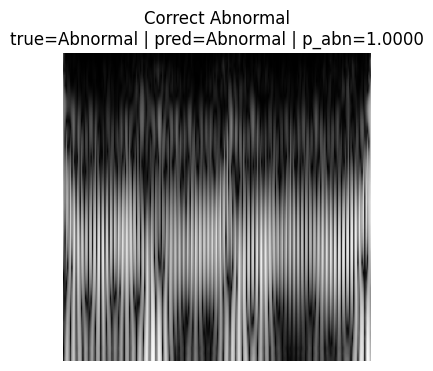

Saved: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\rag_explainability\Pure_CNN\correct_abnormal_retrieved.csv
Saved: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\rag_explainability\Pure_CNN\correct_abnormal_explanation.txt
Correct Normal
Model: Pure_CNN
Source: normal_ecg_images/Normal(235).jpg
True label: Normal
Predicted label: Normal
Probability of Abnormal: 0.002441
Decision Threshold: 0.2850
Retrieved abnormal-case ratio: 0.00%
Retrieved support ratio for predicted label: 100.00%
Retrieved support ratio for true label: 100.00%
The prediction is correct.
The probability is far from the threshold, so the decision confidence is relatively strong.
Most retrieved reference cases are consistent with the predicted label.


,rank,case_id,source_path,true_label_name,pred_label_name,prob_abnormal,similarity
0,1,train_000159,normal_ecg_images/Normal(93).jpg,Normal,Normal,0.002441,1.000000
1,2,train_000662,normal_ecg_images/Normal(240).jpg,Normal,Normal,0.018183,0.996208
2,3,train_000169,normal_ecg_images/Normal(138).jpg,Normal,Normal,0.023465,0.995035
3,4,train_000264,normal_ecg_images/Normal(107).jpg,Normal,Normal,0.001574,0.994010
4,5,train_000568,normal_ecg_images/Normal(212).jpg,Normal,Normal,0.010770,0.991926


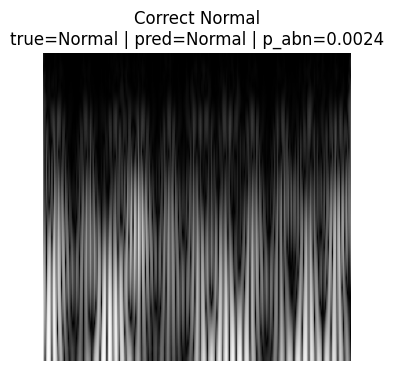

Saved: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\rag_explainability\Pure_CNN\correct_normal_retrieved.csv
Saved: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\rag_explainability\Pure_CNN\correct_normal_explanation.txt
Borderline Case
Model: Pure_CNN
Source: normal_ecg_images/Normal(79).jpg
True label: Normal
Predicted label: Normal
Probability of Abnormal: 0.282348
Decision Threshold: 0.2850
Retrieved abnormal-case ratio: 0.00%
Retrieved support ratio for predicted label: 100.00%
Retrieved support ratio for true label: 100.00%
The prediction is correct.
This sample is close to the operating threshold, so the decision is borderline.
Most retrieved reference cases are consistent with the predicted label.


,rank,case_id,source_path,true_label_name,pred_label_name,prob_abnormal,similarity
0,1,train_000316,normal_ecg_images/Normal(5).jpg,Normal,Normal,0.043852,0.884127
1,2,train_000305,normal_ecg_images/Normal(147).jpg,Normal,Normal,0.043852,0.884127
2,3,train_000443,normal_ecg_images/Normal(163).jpg,Normal,Normal,0.030850,0.868190
3,4,train_000403,normal_ecg_images/Normal(159).jpg,Normal,Normal,0.039478,0.838205
4,5,train_000391,normal_ecg_images/Normal(17).jpg,Normal,Normal,0.039478,0.838205


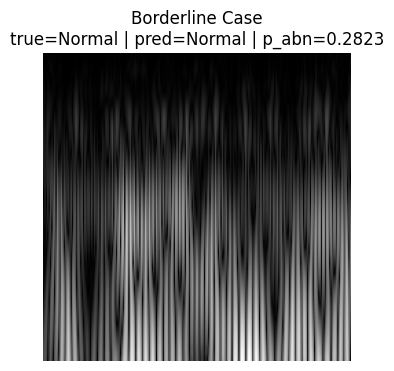

Saved: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\rag_explainability\Pure_CNN\borderline_case_retrieved.csv
Saved: C:\Users\LYG Y9000x\OneDrive\Desktop\proj\outputs_binary\rag_explainability\Pure_CNN\borderline_case_explanation.txt


In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def retrieve_topk_unique(query_embedding, meta_df, index_obj, index_type="faiss", k=5, overfetch=20):
    query_embedding = np.asarray(query_embedding, dtype="float32").reshape(1, -1)
    overfetch = max(overfetch, k)

    if index_type == "faiss":
        import faiss
        q = query_embedding.copy()
        faiss.normalize_L2(q)
        scores, ids = index_obj.search(q, min(overfetch, len(meta_df)))
        ids = ids[0]
        scores = scores[0]
    else:
        n_neighbors = min(overfetch, len(meta_df))
        dist, ids = index_obj.kneighbors(query_embedding, n_neighbors=n_neighbors)
        ids = ids[0]
        scores = 1.0 - dist[0]

    seen_paths = set()
    keep_rows = []

    for idx, score in zip(ids, scores):
        row = meta_df.iloc[int(idx)].to_dict()
        src = row["source_path"]

        if src in seen_paths:
            continue

        seen_paths.add(src)
        row["similarity"] = float(score)
        keep_rows.append(row)

        if len(keep_rows) >= k:
            break

    out = pd.DataFrame(keep_rows).reset_index(drop=True)
    out.insert(0, "rank", np.arange(1, len(out) + 1))
    return out


def build_text_explanation_v2(model_name, row, threshold, retrieved_df):
    pred_label = int(row["pred_label"])
    true_label = int(row["true_label"])
    prob_abn = float(row["prob_abnormal"])

    pred_name = CLASS_NAMES[pred_label]
    true_name = CLASS_NAMES[true_label]

    same_pred_ratio = float((retrieved_df["true_label"].values == pred_label).mean()) if len(retrieved_df) > 0 else 0.0
    same_true_ratio = float((retrieved_df["true_label"].values == true_label).mean()) if len(retrieved_df) > 0 else 0.0
    abnormal_ratio = float((retrieved_df["true_label"].values == 1).mean()) if len(retrieved_df) > 0 else 0.0

    if abs(prob_abn - threshold) < 0.05:
        conf_note = "This sample is close to the operating threshold, so the decision is borderline."
    elif prob_abn >= 0.80 or prob_abn <= 0.20:
        conf_note = "The probability is far from the threshold, so the decision confidence is relatively strong."
    else:
        conf_note = "The decision confidence is moderate."

    if same_pred_ratio >= 0.8:
        retrieval_note = "Most retrieved reference cases are consistent with the predicted label."
    elif same_pred_ratio == 0.0 and same_true_ratio >= 0.8 and pred_label != true_label:
        retrieval_note = "The retrieved evidence contradicts the predicted label and instead aligns with the true label, which makes this case useful for error analysis."
    elif same_pred_ratio >= 0.5:
        retrieval_note = "The retrieved evidence is partially consistent with the predicted label."
    else:
        retrieval_note = "The retrieved evidence is mixed and does not strongly support the predicted label."

    correctness_note = "The prediction is correct." if pred_label == true_label else "The prediction is incorrect, so this case is useful for error analysis."

    txt = (
        f"Model: {model_name}\n"
        f"Source: {row['source_path']}\n"
        f"True label: {true_name}\n"
        f"Predicted label: {pred_name}\n"
        f"Probability of Abnormal: {prob_abn:.6f}\n"
        f"Decision Threshold: {threshold:.4f}\n"
        f"Retrieved abnormal-case ratio: {abnormal_ratio:.2%}\n"
        f"Retrieved support ratio for predicted label: {same_pred_ratio:.2%}\n"
        f"Retrieved support ratio for true label: {same_true_ratio:.2%}\n"
        f"{correctness_note}\n"
        f"{conf_note}\n"
        f"{retrieval_note}"
    )
    return txt


def get_case_image(row, loader):
    batch_idx = int(row["batch_idx"])
    sample_idx = int(row["sample_idx"])

    for b_idx, (imgs, rr, labels, rel) in enumerate(loader):
        if b_idx == batch_idx:
            img = imgs[sample_idx:sample_idx+1]
            rr_one = rr[sample_idx:sample_idx+1]
            label = int(labels[sample_idx].item())
            return img, rr_one, label
    raise ValueError("Case not found in loader.")


def run_case_demo(case_row, case_name, loader=L_te):
    img_cpu, rr_cpu, label = get_case_image(case_row, loader)

    img = img_cpu.to(DEVICE)
    rr = rr_cpu.to(DEVICE)

    with torch.no_grad():
        query_embedding = extract_embedding(demo_model, img, rr)[0].cpu().numpy()

    retrieved_df = retrieve_topk_unique(
        query_embedding=query_embedding,
        meta_df=rag_meta_df,
        index_obj=demo_index,
        index_type=INDEX_TYPE,
        k=TOP_K,
        overfetch=20
    )

    explanation = build_text_explanation_v2(
        model_name=TARGET_MODEL,
        row=case_row,
        threshold=float(THR_MAP[TARGET_MODEL]),
        retrieved_df=retrieved_df
    )

    print("=" * 90)
    print(case_name)
    print(explanation)
    print("=" * 90)
    display(retrieved_df[[
        "rank", "case_id", "source_path",
        "true_label_name", "pred_label_name",
        "prob_abnormal", "similarity"
    ]])

    plt.figure(figsize=(4, 4))
    plt.imshow(img_cpu[0].squeeze().numpy(), cmap="gray")
    plt.title(
        f"{case_name}\ntrue={CLASS_NAMES[int(case_row['true_label'])]} | "
        f"pred={CLASS_NAMES[int(case_row['pred_label'])]} | "
        f"p_abn={float(case_row['prob_abnormal']):.4f}"
    )
    plt.axis("off")
    plt.show()

    save_prefix = RAG_DIR / f"{case_name.replace(' ', '_').lower()}"
    retrieved_df.to_csv(f"{save_prefix}_retrieved.csv", index=False, encoding="utf-8-sig")
    Path(f"{save_prefix}_explanation.txt").write_text(explanation, encoding="utf-8")

    print("Saved:", f"{save_prefix}_retrieved.csv")
    print("Saved:", f"{save_prefix}_explanation.txt")

    return retrieved_df, explanation


retr_abn, txt_abn = run_case_demo(case_abn, "Correct Abnormal")
retr_nor, txt_nor = run_case_demo(case_nor, "Correct Normal")
retr_bor, txt_bor = run_case_demo(case_border, "Borderline Case")